In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Packages

In [ ]:
import numpy as np
import PIL
import random
from sklearn.model_selection import cross_val_score

from PIL import Image
import matplotlib.pyplot as plt
from tensorflow.keras.regularizers import l2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Reshape, Input, Conv2D, MaxPooling2D, Flatten, Dense, GRU
from tensorflow.keras.models import Model
import seaborn as sns
import glob
import sklearn.metrics as metrics
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix, roc_curve, roc_auc_score,auc
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Input, SeparableConv2D, BatchNormalization, Activation, Dense, Flatten, MaxPooling2D
from tensorflow.keras.layers import Add
from keras.layers import BatchNormalization
from keras.layers import ELU
from tensorflow.keras.layers import ReLU
import sys
from google.colab import files
import pandas as pd
from sklearn.preprocessing import label_binarize
import time
import numpy as np
import PIL
from PIL import Image
import matplotlib.pyplot as plt
from tensorflow.keras.regularizers import l2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Reshape, Input, Conv2D, MaxPooling2D, Flatten,  GRU
from tensorflow.keras.models import Model
import seaborn as sns
import glob
import sklearn.metrics as metrics
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Add
from keras.layers import BatchNormalization
from keras.layers import ELU
from tensorflow.keras.layers import ReLU
import sys
from google.colab import files
import pandas as pd
from sklearn.preprocessing import label_binarize
import time
from tensorflow.keras.applications import InceptionV3, ResNet50, EfficientNetB0, DenseNet201, InceptionResNetV2
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import (
    VGG16, ResNet50, MobileNetV2, EfficientNetB0, EfficientNetB3,
    DenseNet121, Xception, NASNetMobile, InceptionV3, ConvNeXtTiny
)
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import numpy as np
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from itertools import combinations
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from sklearn.decomposition import PCA
# from deap import base, creator, tools, algorithms


#Dataset

In [ ]:
# Load the .npy files
x_train = np.load('/content/drive/MyDrive/HAM10000/paper4/dataset/x_train_224.npy')
x_test = np.load('/content/drive/MyDrive/HAM10000/paper4/dataset/x_test_224.npy')
y_train = np.load('/content/drive/MyDrive/HAM10000/paper4/dataset/y_train_f.npy')
y_test = np.load('/content/drive/MyDrive/HAM10000/paper4/dataset/y_test_f.npy')
x_train = x_train.astype('float16')
x_test = x_test.astype('float16')
y_train = y_train.astype('float16')
y_test = y_test.astype('float16')
# Print the shapes
print("x_train.shape:", x_train.shape)
print("y_train.shape:", y_train.shape)
print("x_test.shape:", x_test.shape)
print("y_test.shape:", y_test.shape)


x_train.shape: (37548, 224, 224, 3)
y_train.shape: (37548, 7)
x_test.shape: (2005, 224, 224, 3)
y_test.shape: (2005, 7)


In [ ]:
num_classes=7
class_names = np.array(['AKIEC', 'BCC','BKL','DF','MEL','NV','VASC'])

#GoogleNet--80.5

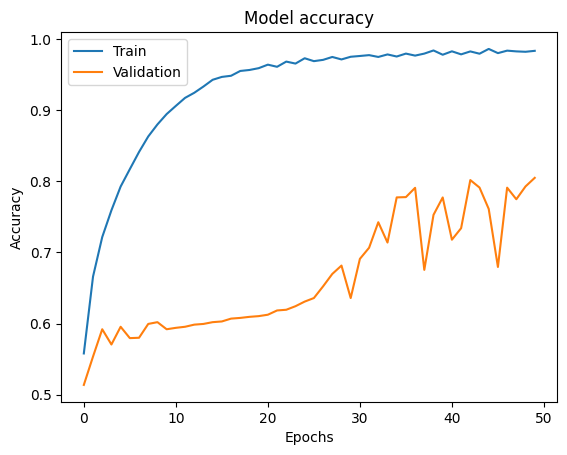

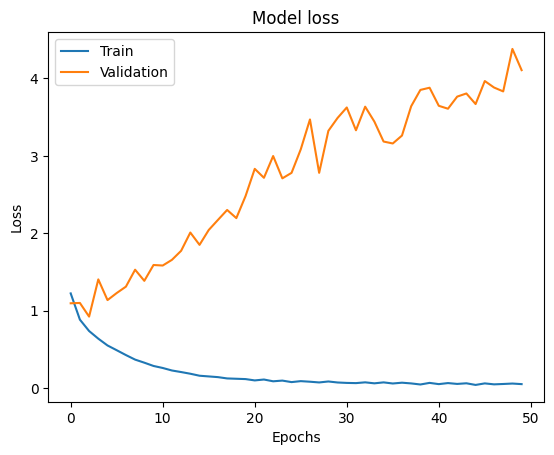

Confusion Matrix:
[[  42   12    3    2    5    2    0]
 [   0   83    6    1    3   10    0]
 [  13   17  142    1   21   25    1]
 [   2    2    1   15    1    2    0]
 [   4   14   14    3  152   36    0]
 [  11   42   58    7   59 1155    9]
 [   0    2    0    0    0    2   25]]


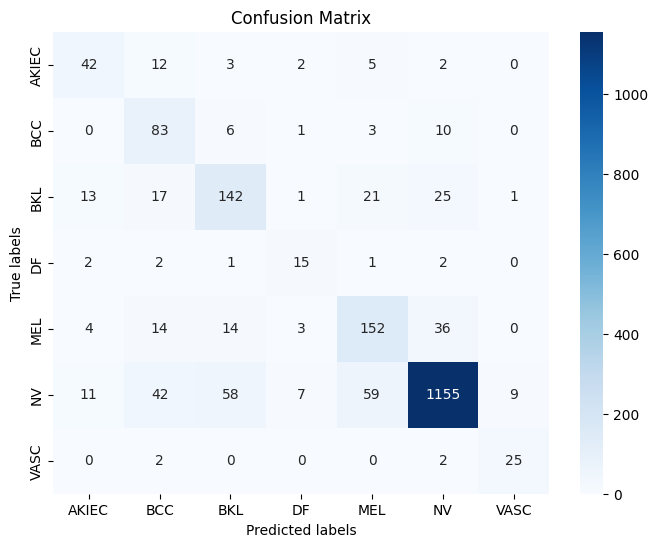


Classification Report:
              precision    recall  f1-score   support

           0     0.5833    0.6364    0.6087        66
           1     0.4826    0.8058    0.6036       103
           2     0.6339    0.6455    0.6396       220
           3     0.5172    0.6522    0.5769        23
           4     0.6307    0.6816    0.6552       223
           5     0.9375    0.8613    0.8978      1341
           6     0.7143    0.8621    0.7812        29

    accuracy                         0.8050      2005
   macro avg     0.6428    0.7350    0.6804      2005
weighted avg     0.8270    0.8050    0.8125      2005



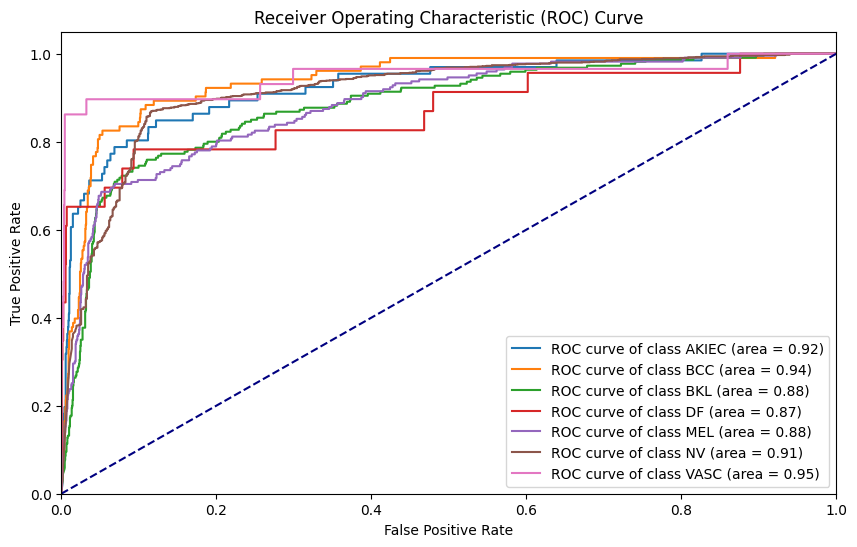

AUC: 0.901
AUC: 0.909


In [ ]:
from tensorflow.keras.optimizers.schedules import ExponentialDecay


# Define a function to create and compile the InceptionV3 model
def create_model(learning_rate=0.001, dropout_rate=0.25):
    # Download InceptionV3 model weights
    base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

    # Save the model weights to a file
    # base_model.save_weights('gnet.weights.h5')

    for layer in base_model.layers[-20:]:
        layer.trainable = True  # Freeze all layers


    # Add your custom classifier on top (can be a few Dense layers)
    # For example:
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(1024, activation='relu')(x)
   
    predictions = Dense(num_classes, activation='softmax')(x)  # Adjust num_classes to your dataset's number of classes


    model = Model(inputs=base_model.input, outputs=predictions)

    # Compile the model with a given learning rate
    optimizer = Adam(learning_rate=0.00001)
    model.compile(optimizer=optimizer, loss= 'categorical_crossentropy', metrics=['accuracy'])


    return model

final_model = create_model()
history = final_model.fit(x_train,y_train, epochs=50, batch_size=16, validation_data=(x_test,y_test), verbose=0)

# final_model.save('/content/drive/MyDrive/HAM10000/paper4/gnet/ham_gnet.h5')


# Plotting training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()
# Plotting training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

#Predict the class probabilities for the test set
y_pred_probs = final_model.predict(x_test)
np.save("/content/drive/MyDrive/HAM10000/paper4/gnet/x_test_prob_gnet_ham.npy",y_pred_probs)
# Convert probabilities to class labels (for classification report and confusion matrix)
y_pred = np.argmax(y_pred_probs, axis=1)
np.save("/content/drive/MyDrive/HAM10000/paper4/gnet/x_test_pred_gnet_ham.npy",y_pred)
y_true = np.argmax(y_test, axis=1)  # Assuming y_test is one-hot encoded

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(conf_matrix)
# Create a heatmap using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4))


# AUC-ROC Curve
y_true_binary = label_binarize(y_true, classes=np.unique(y_true))
n_classes = y_true_binary.shape[1]
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    # fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs.iloc[:, i])
    fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
# Plot ROC curve
plt.figure(figsize=(10, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label='ROC curve of class {0} (area = {1:0.2f})'.format(class_names[i], roc_auc[i]), linestyle='-')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

auc1 = roc_auc_score(y_true, y_pred_probs,multi_class='ovo')
print('AUC: %.3f' % auc1)
auc2 = roc_auc_score(y_true, y_pred_probs,multi_class='ovr')
print('AUC: %.3f' % auc2)



# Densenet201--92.7

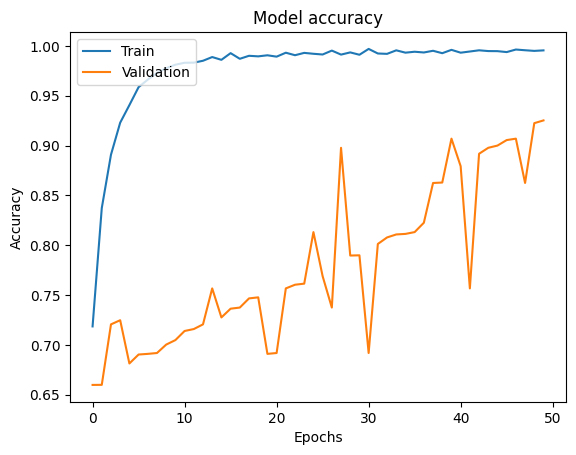

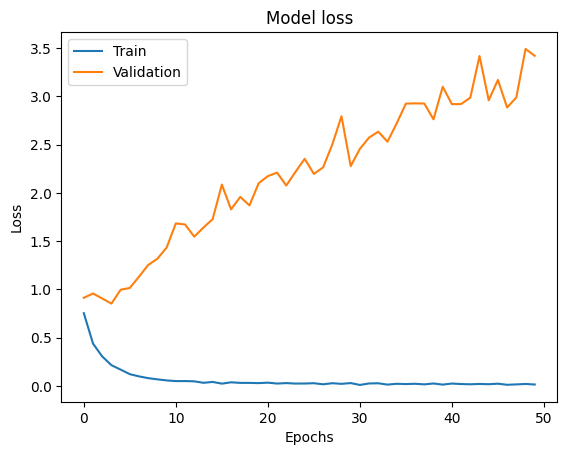

Confusion Matrix:
[[  60    2    2    0    2    0    0]
 [   3   91    2    0    2    5    0]
 [   1    3  196    1   11    7    1]
 [   1    1    0   20    0    1    0]
 [   4    2   10    0  190   15    2]
 [   1   10   23    0   23 1281    3]
 [   0    1    1    0    0    1   26]]


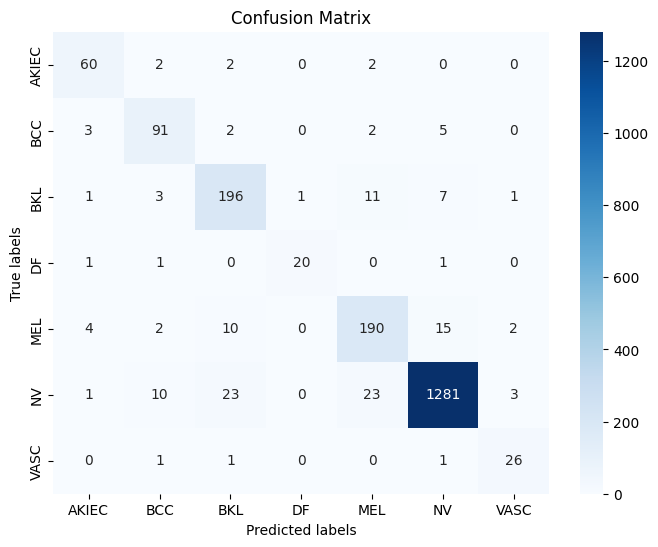


Classification Report:
              precision    recall  f1-score   support

           0     0.8571    0.9091    0.8824        66
           1     0.8273    0.8835    0.8545       103
           2     0.8376    0.8909    0.8634       220
           3     0.9524    0.8696    0.9091        23
           4     0.8333    0.8520    0.8426       223
           5     0.9779    0.9553    0.9664      1341
           6     0.8125    0.8966    0.8525        29

    accuracy                         0.9297      2005
   macro avg     0.8712    0.8938    0.8815      2005
weighted avg     0.9320    0.9297    0.9305      2005



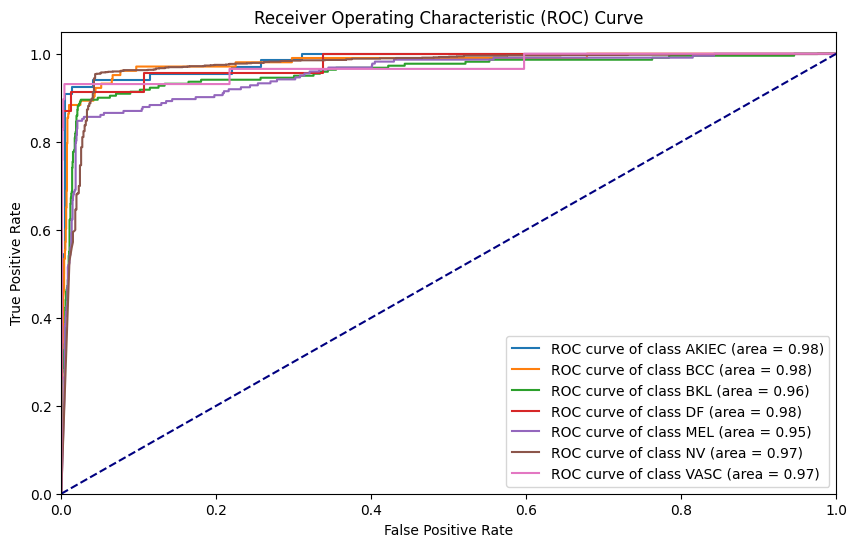

AUC: 0.967
AUC: 0.971


In [ ]:
from tensorflow.keras.optimizers.schedules import ExponentialDecay


# Define a function to create and compile the InceptionV3 model
def create_model(learning_rate=0.001, dropout_rate=0.25):
    # Download InceptionV3 model weights
    base_model = DenseNet201(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

    # Save the model weights to a file
    # base_model.save_weights('gnet.weights.h5')

    for layer in base_model.layers[100:150]:
        layer.trainable = True  # Freeze all layers


    # Add your custom classifier on top (can be a few Dense layers)
    # For example:
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(1024, activation='relu')(x)
#     x = Reshape((-1, 1024))(x)

#     # # Define the GRU layer for sequential processing of image features
#     gru = GRU(512)(x)
    predictions = Dense(num_classes, activation='softmax')(x)  # Adjust num_classes to your dataset's number of classes


    model = Model(inputs=base_model.input, outputs=predictions)

    # Compile the model with a given learning rate
    # optimizer = tf.keras.optimizers.AdamW(learning_rate = 1e-4,weight_decay=1e-4)
    #  Adam(learning_rate=learning_rate)
    
    optimizer = Adam(learning_rate=0.00001)
    model.compile(optimizer=optimizer, loss= 'categorical_crossentropy', metrics=['accuracy'])
    return model

final_model = create_model()
history = final_model.fit(x_train,y_train, epochs=50, batch_size=32, validation_data=(x_test,y_test), verbose=0)

# final_model.save('/content/drive/MyDrive/PAD_UFES_20/paper4/dnet/pad_dnet.h5')


# Plotting training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()
# Plotting training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

#Predict the class probabilities for the test set
y_pred_probs = final_model.predict(x_test)
np.save("/content/drive/MyDrive/HAM10000/paper4/dnet/x_test_prob_dnet_ham.npy",y_pred_probs)
# Convert probabilities to class labels (for classification report and confusion matrix)
y_pred = np.argmax(y_pred_probs, axis=1)
np.save("/content/drive/MyDrive/HAM10000/paper4/dnet/x_test_pred_dnet_ham.npy",y_pred)
y_true = np.argmax(y_test, axis=1)  # Assuming y_test is one-hot encoded

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(conf_matrix)
# Create a heatmap using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4))


# AUC-ROC Curve
y_true_binary = label_binarize(y_true, classes=np.unique(y_true))
n_classes = y_true_binary.shape[1]
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    # fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs.iloc[:, i])
    fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
# Plot ROC curve
plt.figure(figsize=(10, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label='ROC curve of class {0} (area = {1:0.2f})'.format(class_names[i], roc_auc[i]), linestyle='-')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

auc1 = roc_auc_score(y_true, y_pred_probs,multi_class='ovo')
print('AUC: %.3f' % auc1)
auc2 = roc_auc_score(y_true, y_pred_probs,multi_class='ovr')
print('AUC: %.3f' % auc2)




# MobilenetV2--90.9

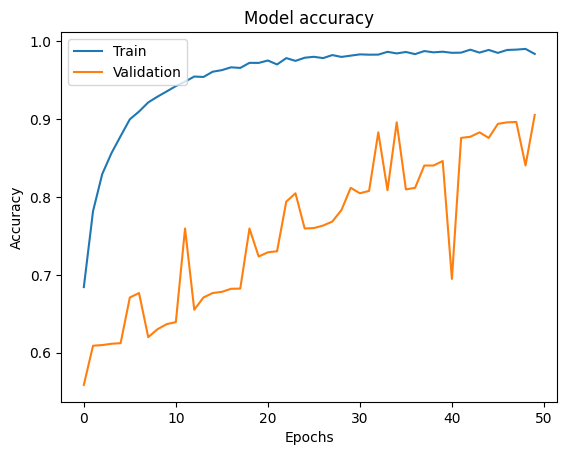

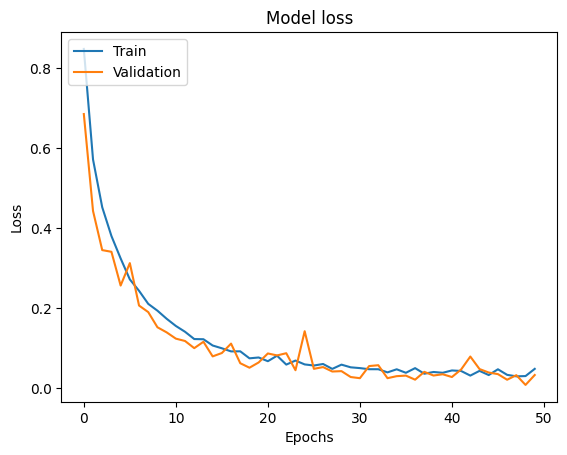

Confusion Matrix:
[[  46    3    7    3    1    6    0]
 [   1   85    3    1    4    9    0]
 [   0    5  172    0    7   36    0]
 [   1    0    1   18    0    3    0]
 [   1    1   11    0  183   27    0]
 [   2    5   17    2   19 1295    1]
 [   0    1    0    1    1    1   25]]


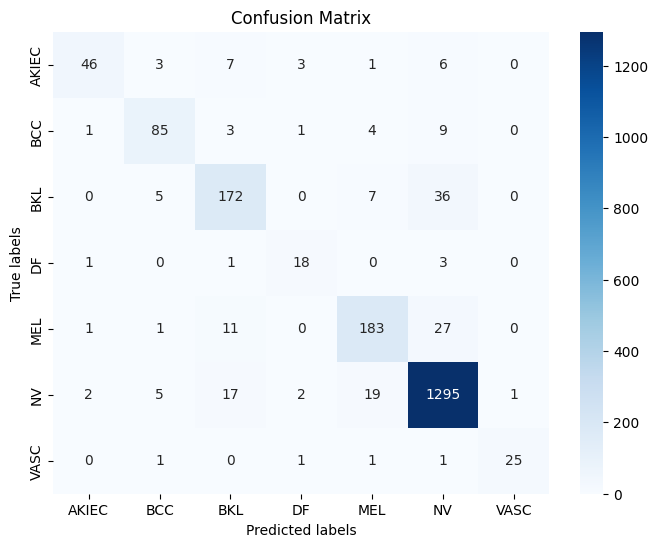


Classification Report:
              precision    recall  f1-score   support

           0     0.9020    0.6970    0.7863        66
           1     0.8500    0.8252    0.8374       103
           2     0.8152    0.7818    0.7981       220
           3     0.7200    0.7826    0.7500        23
           4     0.8512    0.8206    0.8356       223
           5     0.9405    0.9657    0.9529      1341
           6     0.9615    0.8621    0.9091        29

    accuracy                         0.9097      2005
   macro avg     0.8629    0.8193    0.8385      2005
weighted avg     0.9086    0.9097    0.9085      2005



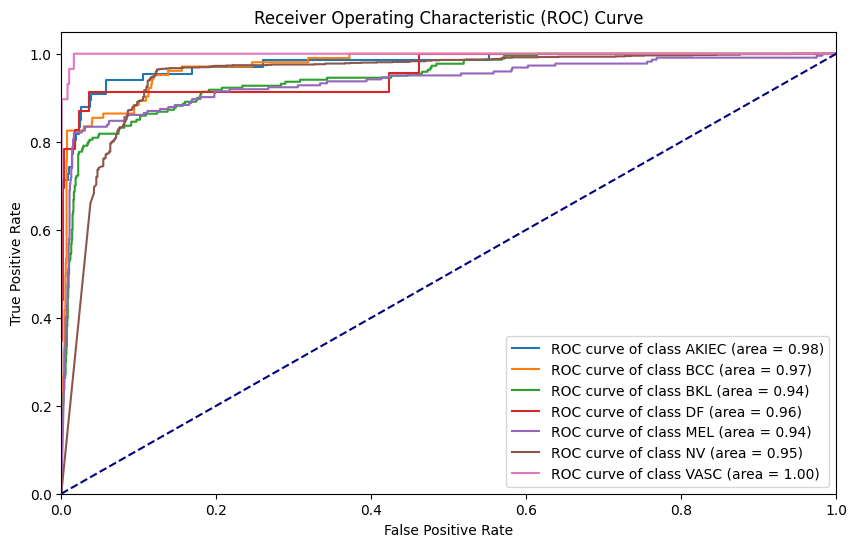

AUC: 0.950
AUC: 0.962


In [ ]:
from tensorflow.keras.optimizers.schedules import ExponentialDecay


# Define a function to create and compile the InceptionV3 model
def create_model(learning_rate=0.001, dropout_rate=0.25):
    # Download InceptionV3 model weights
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

    # Save the model weights to a file
    # base_model.save_weights('gnet.weights.h5')

    for layer in base_model.layers[:-40]:
        layer.trainable = True  # Freeze all layers


    # Add your custom classifier on top (can be a few Dense layers)
    # For example:
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(1024, activation='relu')(x)
#     x = Reshape((-1, 1024))(x)

#     # # Define the GRU layer for sequential processing of image features
#     gru = GRU(512)(x)
    predictions = Dense(num_classes, activation='softmax')(x)  # Adjust num_classes to your dataset's number of classes


    model = Model(inputs=base_model.input, outputs=predictions)

    # Compile the model with a given learning rate
    
    optimizer = Adam(learning_rate=0.00001)
    model.compile(optimizer=optimizer, loss= 'categorical_crossentropy', metrics=['accuracy'])

    return model

final_model = create_model()
history = final_model.fit(x_train,y_train, epochs=50, batch_size=32, validation_data=(x_test,y_test), verbose=0)

# final_model.save('/content/drive/MyDrive/PAD_UFES_20/paper4/mnet/pad_mnet.h5')


# Plotting training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()
# Plotting training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

#Predict the class probabilities for the test set
y_pred_probs = final_model.predict(x_test)
np.save("/content/drive/MyDrive/HAM10000/paper4/mnet/x_test_prob_mnet_ham.npy",y_pred_probs)
# Convert probabilities to class labels (for classification report and confusion matrix)
y_pred = np.argmax(y_pred_probs, axis=1)
np.save("/content/drive/MyDrive/HAM10000/paper4/mnet/x_test_pred_mnet_ham.npy",y_pred)
y_true = np.argmax(y_test, axis=1)  # Assuming y_test is one-hot encoded

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(conf_matrix)
# Create a heatmap using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4))


# AUC-ROC Curve
y_true_binary = label_binarize(y_true, classes=np.unique(y_true))
n_classes = y_true_binary.shape[1]
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    # fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs.iloc[:, i])
    fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
# Plot ROC curve
plt.figure(figsize=(10, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label='ROC curve of class {0} (area = {1:0.2f})'.format(class_names[i], roc_auc[i]), linestyle='-')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

auc1 = roc_auc_score(y_true, y_pred_probs,multi_class='ovo')
print('AUC: %.3f' % auc1)
auc2 = roc_auc_score(y_true, y_pred_probs,multi_class='ovr')
print('AUC: %.3f' % auc2)




# InceptionResnetV2--85.02

In [ ]:
# Assuming x_train is a NumPy array
x_train_resized = tf.image.resize(x_train, (299, 299)).numpy()
x_test_resized = tf.image.resize(x_test, (299, 299)).numpy()
x_train1 = x_train_resized
x_test1 = x_test_resized

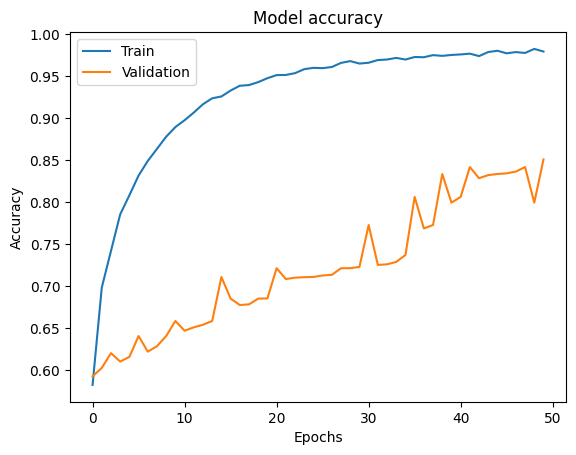

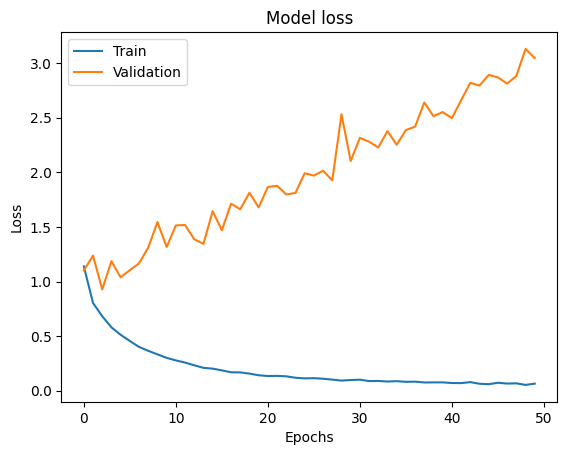

Confusion Matrix:
[[  58    2    2    0    2    2    0]
 [   2   86   10    0    0    5    0]
 [   9    9  173    1   16   12    0]
 [   2    2    2   15    0    2    0]
 [   7    2   10    0  182   22    0]
 [   9   33   52    2   76 1166    3]
 [   0    1    1    0    0    1   26]]


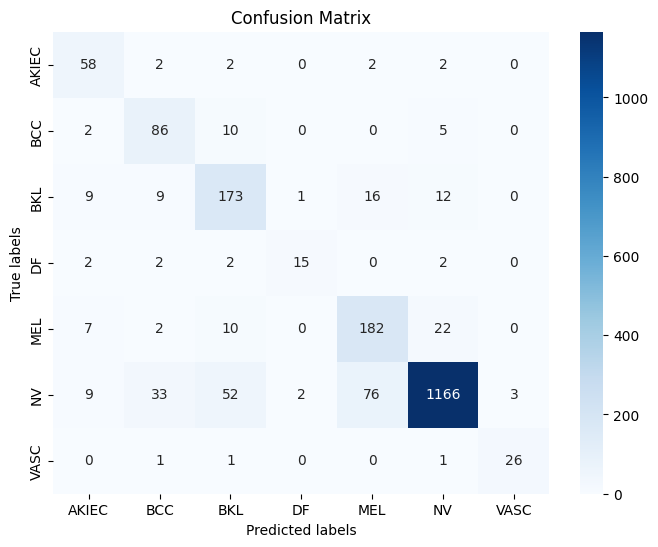


Classification Report:
              precision    recall  f1-score   support

           0     0.6667    0.8788    0.7582        66
           1     0.6370    0.8350    0.7227       103
           2     0.6920    0.7864    0.7362       220
           3     0.8333    0.6522    0.7317        23
           4     0.6594    0.8161    0.7295       223
           5     0.9636    0.8695    0.9142      1341
           6     0.8966    0.8966    0.8966        29

    accuracy                         0.8509      2005
   macro avg     0.7641    0.8192    0.7841      2005
weighted avg     0.8710    0.8509    0.8568      2005



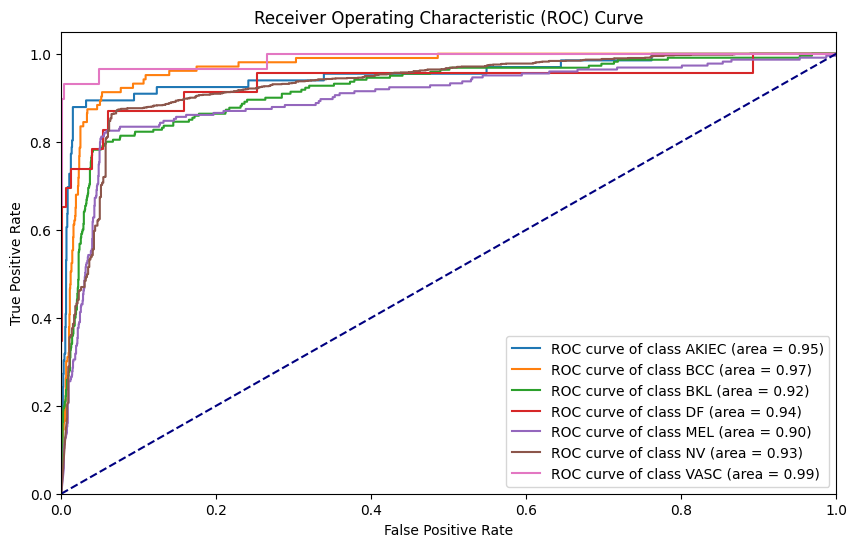

AUC: 0.942
AUC: 0.942


In [ ]:
from tensorflow.keras.optimizers.schedules import ExponentialDecay


# Define a function to create and compile the InceptionV3 model
def create_model(learning_rate=0.001, dropout_rate=0.25):
    # Download InceptionV3 model weights
    base_model = InceptionResNetV2(weights='imagenet', include_top=False, input_shape=(299, 299, 3))

    # Save the model weights to a file
    # base_model.save_weights('gnet.weights.h5')

    for layer in base_model.layers[:200]:
        layer.trainable = False  # Freeze all layers


    # Add your custom classifier on top (can be a few Dense layers)
    # For example:
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(1024, activation='relu')(x)
#     x = Reshape((-1, 1024))(x)

#     # # Define the GRU layer for sequential processing of image features
#     gru = GRU(512)(x)
    predictions = Dense(num_classes, activation='softmax')(x)  # Adjust num_classes to your dataset's number of classes


    model = Model(inputs=base_model.input, outputs=predictions)

    # Compile the model with a given learning rate
    
    optimizer = Adam(learning_rate=0.00001)
    model.compile(optimizer=optimizer, loss= 'categorical_crossentropy', metrics=['accuracy'])

    return model

final_model = create_model()
history = final_model.fit(x_train1,y_train, epochs=50, batch_size=32, validation_data=(x_test1,y_test), verbose=0)

# final_model.save('/content/drive/MyDrive/PAD_UFES_20/paper4/irnet/pad_irnet.h5')


# Plotting training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()
# Plotting training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

#Predict the class probabilities for the test set
y_pred_probs = final_model.predict(x_test1)
np.save("/content/drive/MyDrive/HAM10000/paper4/irnet/x_test_prob_irnet_ham.npy",y_pred_probs)
# Convert probabilities to class labels (for classification report and confusion matrix)
y_pred = np.argmax(y_pred_probs, axis=1)
np.save("/content/drive/MyDrive/HAM10000/paper4/irnet/x_test_pred_irnet_ham.npy",y_pred)
y_true = np.argmax(y_test, axis=1)  # Assuming y_test is one-hot encoded

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(conf_matrix)
# Create a heatmap using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4))


# AUC-ROC Curve
y_true_binary = label_binarize(y_true, classes=np.unique(y_true))
n_classes = y_true_binary.shape[1]
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    # fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs.iloc[:, i])
    fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
# Plot ROC curve
plt.figure(figsize=(10, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label='ROC curve of class {0} (area = {1:0.2f})'.format(class_names[i], roc_auc[i]), linestyle='-')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

auc1 = roc_auc_score(y_true, y_pred_probs,multi_class='ovo')
print('AUC: %.3f' % auc1)
auc2 = roc_auc_score(y_true, y_pred_probs,multi_class='ovr')
print('AUC: %.3f' % auc2)


#NasNetMobile--83.4

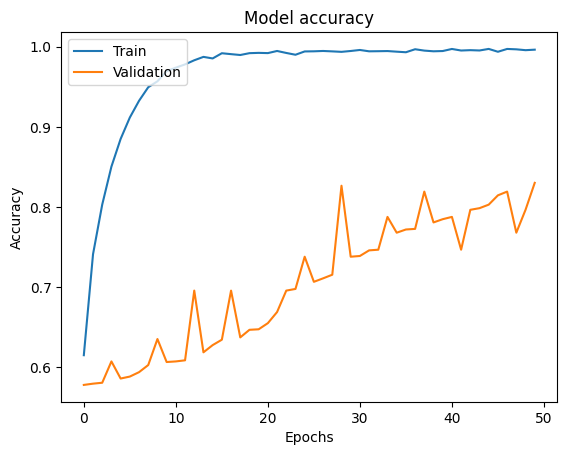

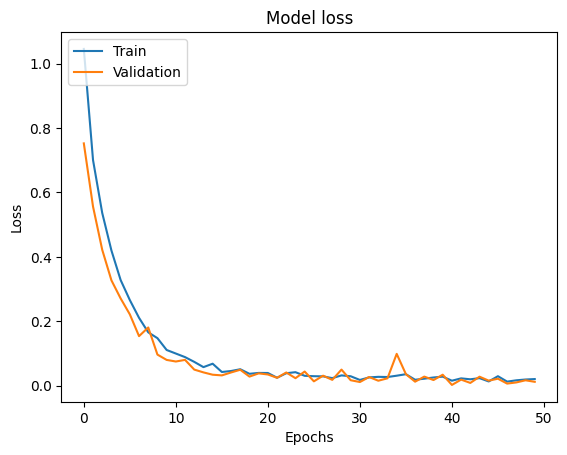

Confusion Matrix:
[[  49    3    6    0    6    1    1]
 [   4   84    6    2    3    3    1]
 [   6    8  163    8   12   22    1]
 [   1    1    4   14    1    2    0]
 [   7    6   11    3  180   15    1]
 [  10   18   49   10   82 1159   13]
 [   0    0    1    1    1    1   25]]


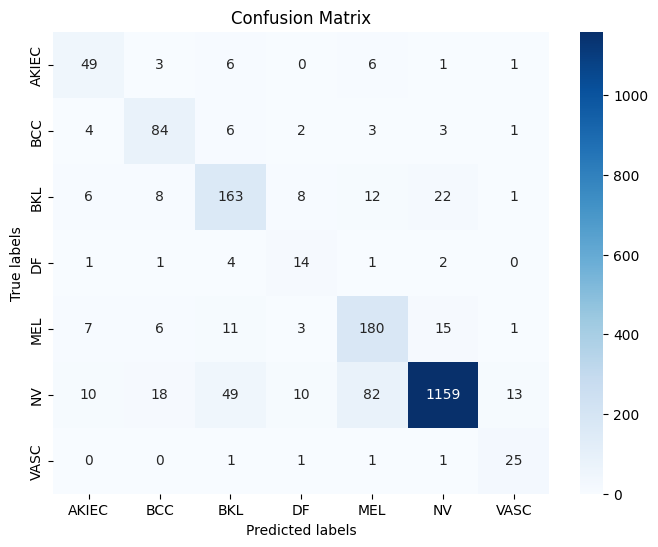


Classification Report:
              precision    recall  f1-score   support

           0     0.6364    0.7424    0.6853        66
           1     0.7000    0.8155    0.7534       103
           2     0.6792    0.7409    0.7087       220
           3     0.3684    0.6087    0.4590        23
           4     0.6316    0.8072    0.7087       223
           5     0.9634    0.8643    0.9112      1341
           6     0.5952    0.8621    0.7042        29

    accuracy                         0.8349      2005
   macro avg     0.6535    0.7773    0.7043      2005
weighted avg     0.8589    0.8349    0.8427      2005



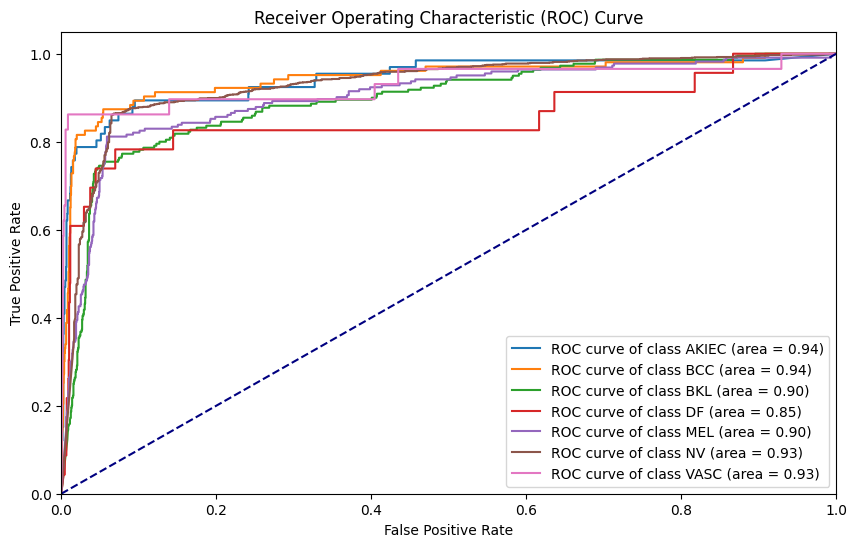

AUC: 0.906
AUC: 0.914


In [ ]:
from tensorflow.keras.optimizers.schedules import ExponentialDecay


# Define a function to create and compile the InceptionV3 model
def create_model(learning_rate=0.001, dropout_rate=0.25):
    # Download InceptionV3 model weights
    base_model = NASNetMobile(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

    # Save the model weights to a file
    # base_model.save_weights('gnet.weights.h5')

    for layer in base_model.layers[:-50]:
        layer.trainable = True  # Freeze all layers


    # Add your custom classifier on top (can be a few Dense layers)
    # For example:
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(1024, activation='relu')(x)
#     x = Reshape((-1, 1024))(x)

#     # # Define the GRU layer for sequential processing of image features
#     gru = GRU(512)(x)
    predictions = Dense(num_classes, activation='softmax')(x)  # Adjust num_classes to your dataset's number of classes


    model = Model(inputs=base_model.input, outputs=predictions)

    # Compile the model with a given learning rate
   
    optimizer = Adam(learning_rate=0.00001)
    model.compile(optimizer=optimizer, loss= 'categorical_crossentropy', metrics=['accuracy'])

    return model

final_model = create_model()
history = final_model.fit(x_train,y_train, epochs=50, batch_size=32, validation_data=(x_test,y_test), verbose=0)

# final_model.save('/content/drive/MyDrive/PAD_UFES_20/paper4/nnet/pad_nnet.h5')


# Plotting training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()
# Plotting training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

#Predict the class probabilities for the test set
y_pred_probs = final_model.predict(x_test)
np.save("/content/drive/MyDrive/HAM10000/paper4/nnet/x_test_prob_nnet_ham.npy",y_pred_probs)
# Convert probabilities to class labels (for classification report and confusion matrix)
y_pred = np.argmax(y_pred_probs, axis=1)
np.save("/content/drive/MyDrive/HAM10000/paper4/nnet/x_test_pred_nnet_ham.npy",y_pred)
y_true = np.argmax(y_test, axis=1)  # Assuming y_test is one-hot encoded

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(conf_matrix)
# Create a heatmap using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4))


# AUC-ROC Curve
y_true_binary = label_binarize(y_true, classes=np.unique(y_true))
n_classes = y_true_binary.shape[1]
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    # fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs.iloc[:, i])
    fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
# Plot ROC curve
plt.figure(figsize=(10, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label='ROC curve of class {0} (area = {1:0.2f})'.format(class_names[i], roc_auc[i]), linestyle='-')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

auc1 = roc_auc_score(y_true, y_pred_probs,multi_class='ovo')
print('AUC: %.3f' % auc1)
auc2 = roc_auc_score(y_true, y_pred_probs,multi_class='ovr')
print('AUC: %.3f' % auc2)


# MBHCNN--92.07

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_72 (Conv2D)        │ (None, 224, 224, 32)   │            896 │ input_layer_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_66    │ (None, 224, 224, 32)   │            128 │ conv2d_72[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_36          │ (None, 112, 112, 32)   │              0 │ batch_normalization_6… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_73 (Conv2D)        │ (None, 112, 112, 64)   │         18,496 │ max_pooling2d_36[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_67    │ (None, 112, 112, 64)   │            256 │ conv2d_73[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_37          │ (None, 56, 56, 64)     │              0 │ batch_normalization_6… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv2d_51       │ (None, 56, 56, 64)     │          4,736 │ max_pooling2d_37[0][0] │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_74    │ (None, 56, 56, 64)     │            256 │ separable_conv2d_51[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ elu_29 (ELU)              │ (None, 56, 56, 64)     │              0 │ batch_normalization_7… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_74 (Conv2D)        │ (None, 56, 56, 128)    │         73,856 │ max_pooling2d_37[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_76 (Conv2D)        │ (None, 112, 112, 32)   │          9,216 │ max_pooling2d_36[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv2d_52       │ (None, 56, 56, 64)     │          4,736 │ elu_29[0][0]           │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_68    │ (None, 56, 56, 128)    │            512 │ conv2d_74[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_70    │ (None, 112, 112, 32)   │            128 │ conv2d_76[0][0]        │
│ (BatchNormalization) 

 Total params: 7,372,270 (28.12 MB)

 Trainable params: 7,362,542 (28.09 MB)

 Non-trainable params: 9,728 (38.00 KB)

Total number of layers: 108


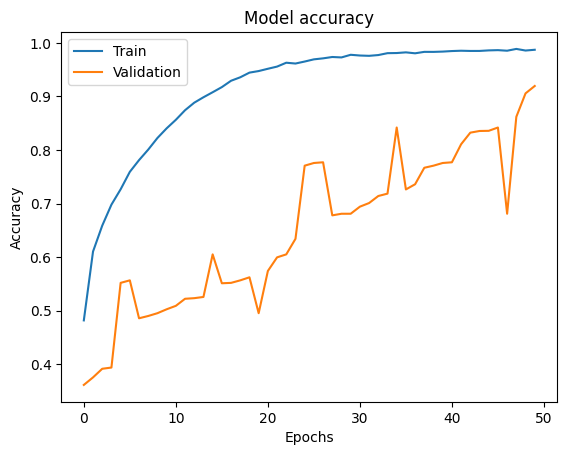

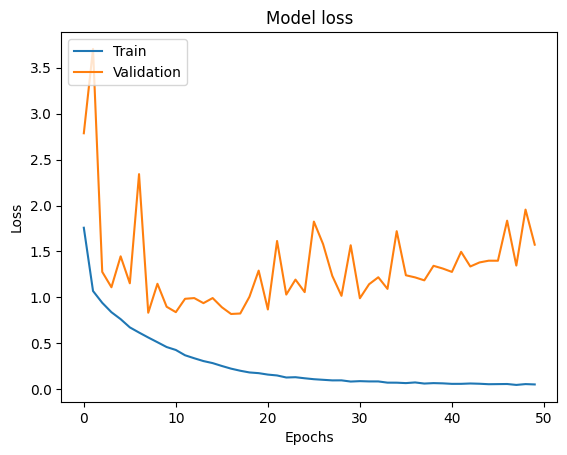

Confusion Matrix:
[[  57    3    2    1    2    1    0]
 [   2   97    1    0    3    0    0]
 [   5    7  191    1   10    6    0]
 [   0    2    0   20    0    1    0]
 [   5    1    7    2  194   14    0]
 [   4   12   11    2   53 1259    0]
 [   0    1    0    0    0    0   28]]


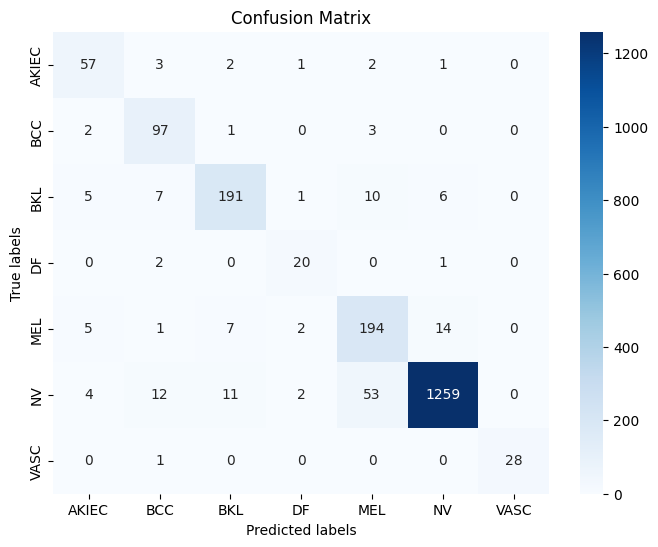


Classification Report:
              precision    recall  f1-score   support

           0     0.7808    0.8636    0.8201        66
           1     0.7886    0.9417    0.8584       103
           2     0.9009    0.8682    0.8843       220
           3     0.7692    0.8696    0.8163        23
           4     0.7405    0.8700    0.8000       223
           5     0.9828    0.9389    0.9603      1341
           6     1.0000    0.9655    0.9825        29

    accuracy                         0.9207      2005
   macro avg     0.8518    0.9025    0.8746      2005
weighted avg     0.9281    0.9207    0.9230      2005



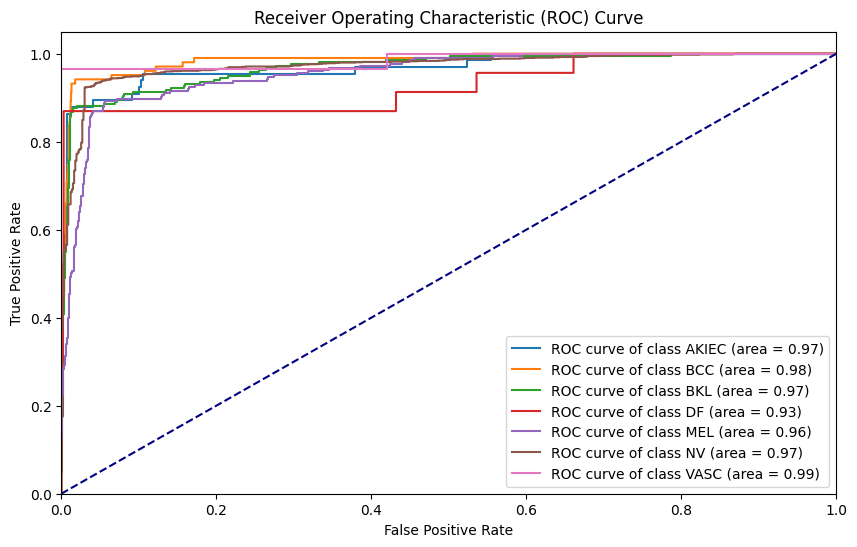

AUC: 0.963
AUC: 0.966


In [ ]:
# without GRU
def residual_block(x, filters, y=None):
    if y is None:
        y = x  # Set y to x if y is not provided
    shortcut = y
    x = Conv2D(filters, (3, 3), padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = ELU()(x)
    x = Conv2D(filters, (3, 3), padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    return Add()([x, shortcut])

# Xception Block
def xception_block(x, filters):
    for _ in range(3):
        x = layers.SeparableConv2D(filters, (3, 3), padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.ELU()(x)
    return x

# Squeeze-Excite Block
def squeeze_excite_block(x, ratio=16):
    filters = x.shape[-1]
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(filters // ratio, activation='elu')(se)
    se = layers.Dense(filters, activation='sigmoid')(se)
    return layers.multiply([x, se])

# MBConv Block (MobileNetV2)
def mbconv_block(x, filters, expansion_factor=6):
    input_filters = x.shape[-1]
    expanded_filters = input_filters * expansion_factor
    x = layers.Conv2D(expanded_filters, (1, 1), padding='same', activation='elu')(x)
    x = layers.DepthwiseConv2D((3, 3), padding='same')(x)
    x = layers.Conv2D(filters, (1, 1), padding='same', activation='linear')(x)
    return x

# Ghost Block
def ghost_block(x, filters):
    primary = layers.Conv2D(filters // 2, (1, 1), padding='same')(x)
    cheap_operation = layers.DepthwiseConv2D((3, 3), padding='same')(primary)
    return layers.concatenate([primary, cheap_operation])

# Fire Block (SqueezeNet)
def fire_block(x, squeeze_filters, expand_filters):
    x = layers.Conv2D(squeeze_filters, (1, 1), activation='elu')(x)
    expand1x1 = layers.Conv2D(expand_filters, (1, 1), activation='elu')(x)
    expand3x3 = layers.Conv2D(expand_filters, (3, 3), padding='same', activation='elu')(x)
    return layers.concatenate([expand1x1, expand3x3])

# Depthwise Separable Convolution Block
def dsc_block(x, filters):
    x = layers.SeparableConv2D(filters, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ELU()(x)
    return x

# Build the full model
def build_model(input_shape=(224, 224, 3), num_classes=6):
    inputs = layers.Input(shape=input_shape)

    # Initial Convolution and Pooling
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x32 = layers.MaxPooling2D(pool_size=(2, 2))(x)  # Shape: (64, 64, 32)

    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x32)
    x = layers.BatchNormalization()(x)
    x64 = layers.MaxPooling2D(pool_size=(2, 2))(x)  # Shape: (32, 32, 64)

    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x64)
    x = layers.BatchNormalization()(x)
    x128 = layers.MaxPooling2D(pool_size=(2, 2))(x)  # Shape: (16, 16, 128)

    x = layers.Conv2D(256, (3, 3), padding='same', activation='relu')(x128)
    x = layers.BatchNormalization()(x)
    x256 = layers.MaxPooling2D(pool_size=(2, 2))(x)  # Shape: (08, 08, 256)

    # Block 1: Residual + MBConv + Depthwise Separable Convolution
    x1 = residual_block(x32, 32)
    x1 = SeparableConv2D(32, (3, 3), padding='same',
                    depthwise_regularizer=l2(0.01),
                    pointwise_regularizer=l2(0.01))(x1)
    x1 = mbconv_block(x1, 32)
    mbconv1 = Conv2D(64,(3,3),padding="same")(x1)
    mbconv1 = layers.MaxPooling2D(pool_size=(2, 2))(mbconv1)
    x1 = SeparableConv2D(32, (3, 3), padding='same',
                    depthwise_regularizer=l2(0.01),
                    pointwise_regularizer=l2(0.01))(x1)
    x1 = dsc_block(x1,32)
    x1 = Conv2D(256, (3, 3), padding='same')(x1)
    x1 = BatchNormalization()(x1)
    x1 = layers.ReLU()(x1)

    # Block 2: Xception + res + dsc
    x2 = xception_block(x64, 64)
    x2 = SeparableConv2D(64, (3, 3), padding='same',
                    depthwise_regularizer=l2(0.01),
                    pointwise_regularizer=l2(0.01))(x2)
    x2 = residual_block(x2, 64,mbconv1)
    x2 = SeparableConv2D(64, (3, 3), padding='same',
                    depthwise_regularizer=l2(0.01),
                    pointwise_regularizer=l2(0.01))(x2)
    x2 = mbconv_block(x2, 64)
    x2 = Conv2D(256, (3, 3), padding='same')(x2)
    x2 = BatchNormalization()(x2)
    x2 = layers.ReLU()(x2)

    # Block 3: SE + MBConv + Depthwise Separable Convolution
    x3 = squeeze_excite_block(x128)
    x3 = SeparableConv2D(128, (3, 3), padding='same',
                    depthwise_regularizer=l2(0.01),
                    pointwise_regularizer=l2(0.01))(x3)
    x3 = mbconv_block(x3, 128)
    mbconv3 = Conv2D(256,(3,3),padding="same")(x3)
    mbconv3 = layers.MaxPooling2D(pool_size=(2, 2))(mbconv3)
    x3 = SeparableConv2D(128, (3, 3), padding='same',
                    depthwise_regularizer=l2(0.01),
                    pointwise_regularizer=l2(0.01))(x3)
    x3 = dsc_block(x3, 128)
    x3 = Conv2D(256, (3, 3), padding='same')(x3)
    x3 = BatchNormalization()(x3)
    x3 = layers.ReLU()(x3)

    # Block 4: MBConv + Residual + Depthwise Separable Convolution
    x4 = mbconv_block(x256, 256)
    x4 = SeparableConv2D(256, (3, 3), padding='same',
                    depthwise_regularizer=l2(0.01),
                    pointwise_regularizer=l2(0.01))(x4)
    x4 = residual_block(x4, 256,mbconv3)
    x4 = SeparableConv2D(256, (3, 3), padding='same',
                    depthwise_regularizer=l2(0.01),
                    pointwise_regularizer=l2(0.01))(x4)
    x4 = dsc_block(x4, 256)
    x4 = Conv2D(256, (3, 3), padding='same')(x4)
    x4 = BatchNormalization()(x4)
    x4 = layers.ReLU()(x4)

    # Concatenate all blocks
    x1=layers.MaxPooling2D(pool_size=(2, 2))(x1)
    x1=layers.MaxPooling2D(pool_size=(2, 2))(x1)
    x1=layers.MaxPooling2D(pool_size=(2, 2))(x1)
    x2=layers.MaxPooling2D(pool_size=(2, 2))(x2)
    x2=layers.MaxPooling2D(pool_size=(2, 2))(x2)
    x3=layers.MaxPooling2D(pool_size=(2, 2))(x3)
    concatenated = layers.concatenate([x1, x2, x3, x4], axis=-1)

    x = SeparableConv2D(1024, (3, 3), padding='same')(concatenated)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SeparableConv2D(1024, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)


    # Classifier
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    
    optimizer = Adam(learning_rate=0.00001)
    model.compile(optimizer=optimizer, loss= 'categorical_crossentropy', metrics=['accuracy'])
    return model

# Build and compile the model
model = build_model(input_shape=(224, 224, 3), num_classes=6)

# model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Print the model summary
model.summary()

total_layers = len(model.layers)
print("Total number of layers:", total_layers)

final_model = build_model(input_shape=(224, 224, 3), num_classes=6)
history = final_model.fit(x_train,y_train, epochs=50, batch_size=32, validation_data=(x_test,y_test), verbose=0)

# final_model.save('/content/drive/MyDrive/PAD_UFES_20/paper4/ccnn/pad_ccnn.h5')


# Plotting training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()
# Plotting training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

#Predict the class probabilities for the test set
y_pred_probs = final_model.predict(x_test)
np.save("/content/drive/MyDrive/HAM10000/paper4/ccnn/x_test_prob_ccnn_ham.npy",y_pred_probs)
# Convert probabilities to class labels (for classification report and confusion matrix)
y_pred = np.argmax(y_pred_probs, axis=1)
np.save("/content/drive/MyDrive/HAM10000/paper4/ccnn/x_test_pred_ccnn_ham.npy",y_pred)
y_true = np.argmax(y_test, axis=1)  # Assuming y_test is one-hot encoded

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(conf_matrix)
# Create a heatmap using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4))


# AUC-ROC Curve
y_true_binary = label_binarize(y_true, classes=np.unique(y_true))
n_classes = y_true_binary.shape[1]
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    # fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs.iloc[:, i])
    fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
# Plot ROC curve
plt.figure(figsize=(10, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label='ROC curve of class {0} (area = {1:0.2f})'.format(class_names[i], roc_auc[i]), linestyle='-')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

auc1 = roc_auc_score(y_true, y_pred_probs,multi_class='ovo')
print('AUC: %.3f' % auc1)
auc2 = roc_auc_score(y_true, y_pred_probs,multi_class='ovr')
print('AUC: %.3f' % auc2)


#MBHCNNGRU--96.01

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_48 (Conv2D)        │ (None, 224, 224, 32)   │            896 │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_44    │ (None, 224, 224, 32)   │            128 │ conv2d_48[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_24          │ (None, 112, 112, 32)   │              0 │ batch_normalization_4… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_49 (Conv2D)        │ (None, 112, 112, 64)   │         18,496 │ max_pooling2d_24[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_45    │ (None, 112, 112, 64)   │            256 │ conv2d_49[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_25          │ (None, 56, 56, 64)     │              0 │ batch_normalization_4… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv2d_35       │ (None, 56, 56, 64)     │          4,736 │ max_pooling2d_25[0][0] │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_52    │ (None, 56, 56, 64)     │            256 │ separable_conv2d_35[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ elu_20 (ELU)              │ (None, 56, 56, 64)     │              0 │ batch_normalization_5… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_50 (Conv2D)        │ (None, 56, 56, 128)    │         73,856 │ max_pooling2d_25[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_52 (Conv2D)        │ (None, 112, 112, 32)   │          9,216 │ max_pooling2d_24[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ separable_conv2d_36       │ (None, 56, 56, 64)     │          4,736 │ elu_20[0][0]           │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_46    │ (None, 56, 56, 128)    │            512 │ conv2d_50[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_48    │ (None, 112, 112, 32)   │            128 │ conv2d_52[0][0]        │
│ (BatchNormalization) 

 Total params: 8,948,719 (34.14 MB)

 Trainable params: 8,938,991 (34.10 MB)

 Non-trainable params: 9,728 (38.00 KB)

Total number of layers: 109


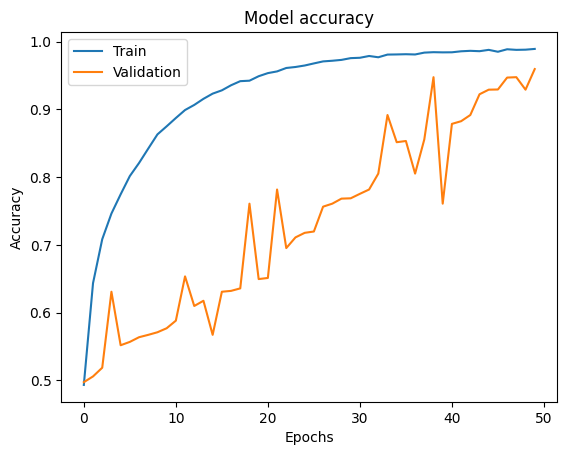

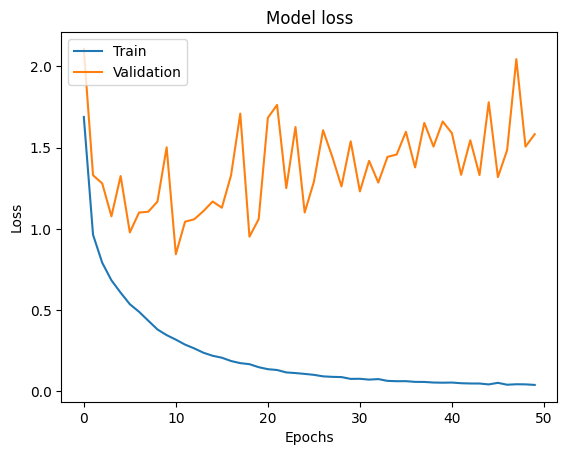

Confusion Matrix:
[[  61    1    1    0    2    1    0]
 [   1   95    3    1    1    2    0]
 [   2    3  201    0    9    5    0]
 [   1    0    1   18    0    2    1]
 [   0    1    4    0  208   10    0]
 [   0    4    4    0   16 1315    2]
 [   0    1    0    0    0    1   27]]


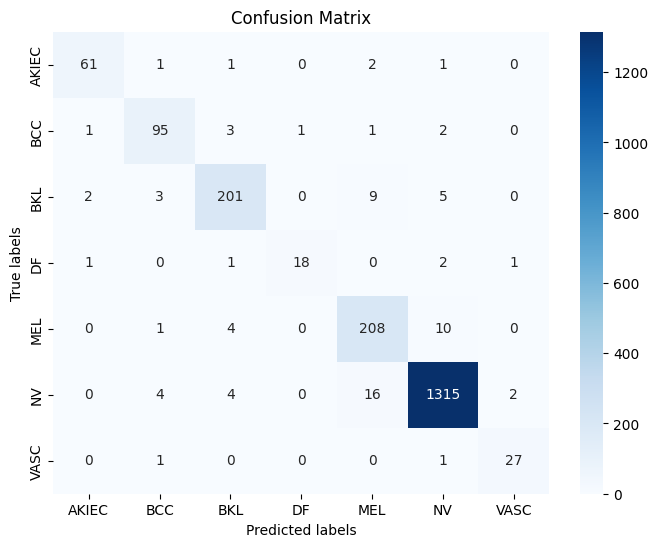


Classification Report:
              precision    recall  f1-score   support

           0     0.9385    0.9242    0.9313        66
           1     0.9048    0.9223    0.9135       103
           2     0.9393    0.9136    0.9263       220
           3     0.9474    0.7826    0.8571        23
           4     0.8814    0.9327    0.9063       223
           5     0.9843    0.9806    0.9824      1341
           6     0.9000    0.9310    0.9153        29

    accuracy                         0.9601      2005
   macro avg     0.9279    0.9125    0.9189      2005
weighted avg     0.9607    0.9601    0.9602      2005



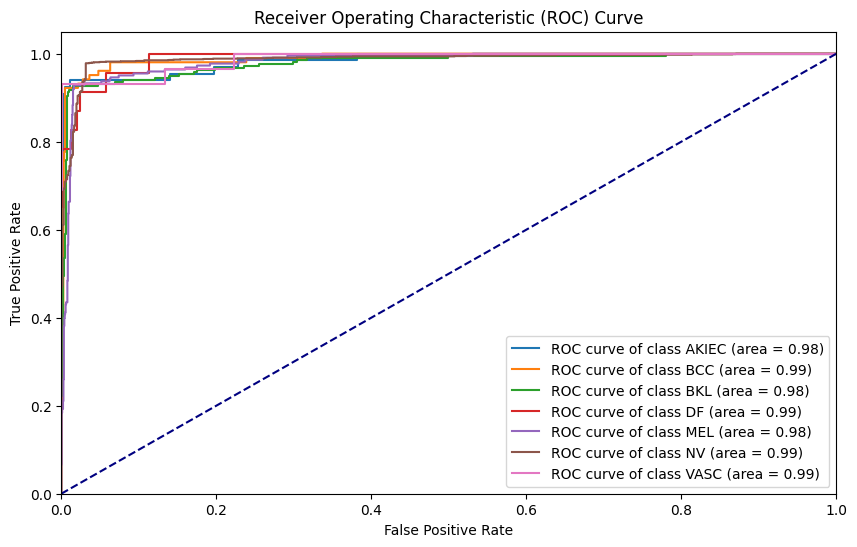

AUC: 0.980
AUC: 0.986


In [ ]:
# without GRU
def residual_block(x, filters, y=None):
    if y is None:
        y = x  # Set y to x if y is not provided
    shortcut = y
    x = Conv2D(filters, (3, 3), padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = ELU()(x)
    x = Conv2D(filters, (3, 3), padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    return Add()([x, shortcut])

# Xception Block
def xception_block(x, filters):
    for _ in range(3):
        x = layers.SeparableConv2D(filters, (3, 3), padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.ELU()(x)
    return x

# Squeeze-Excite Block
def squeeze_excite_block(x, ratio=16):
    filters = x.shape[-1]
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(filters // ratio, activation='elu')(se)
    se = layers.Dense(filters, activation='sigmoid')(se)
    return layers.multiply([x, se])

# MBConv Block (MobileNetV2)
def mbconv_block(x, filters, expansion_factor=6):
    input_filters = x.shape[-1]
    expanded_filters = input_filters * expansion_factor
    x = layers.Conv2D(expanded_filters, (1, 1), padding='same', activation='elu')(x)
    x = layers.DepthwiseConv2D((3, 3), padding='same')(x)
    x = layers.Conv2D(filters, (1, 1), padding='same', activation='linear')(x)
    return x

# Ghost Block
def ghost_block(x, filters):
    primary = layers.Conv2D(filters // 2, (1, 1), padding='same')(x)
    cheap_operation = layers.DepthwiseConv2D((3, 3), padding='same')(primary)
    return layers.concatenate([primary, cheap_operation])

# Fire Block (SqueezeNet)
def fire_block(x, squeeze_filters, expand_filters):
    x = layers.Conv2D(squeeze_filters, (1, 1), activation='elu')(x)
    expand1x1 = layers.Conv2D(expand_filters, (1, 1), activation='elu')(x)
    expand3x3 = layers.Conv2D(expand_filters, (3, 3), padding='same', activation='elu')(x)
    return layers.concatenate([expand1x1, expand3x3])

# Depthwise Separable Convolution Block
def dsc_block(x, filters):
    x = layers.SeparableConv2D(filters, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ELU()(x)
    return x

# Build the full model
def build_model(input_shape=(224, 224, 3), num_classes=7):
    inputs = layers.Input(shape=input_shape)

    # Initial Convolution and Pooling
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x32 = layers.MaxPooling2D(pool_size=(2, 2))(x)  # Shape: (64, 64, 32)

    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x32)
    x = layers.BatchNormalization()(x)
    x64 = layers.MaxPooling2D(pool_size=(2, 2))(x)  # Shape: (32, 32, 64)

    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x64)
    x = layers.BatchNormalization()(x)
    x128 = layers.MaxPooling2D(pool_size=(2, 2))(x)  # Shape: (16, 16, 128)

    x = layers.Conv2D(256, (3, 3), padding='same', activation='relu')(x128)
    x = layers.BatchNormalization()(x)
    x256 = layers.MaxPooling2D(pool_size=(2, 2))(x)  # Shape: (08, 08, 256)

    # Block 1: Residual + MBConv + Depthwise Separable Convolution
    x1 = residual_block(x32, 32)
    x1 = SeparableConv2D(32, (3, 3), padding='same',
                    depthwise_regularizer=l2(0.01),
                    pointwise_regularizer=l2(0.01))(x1)
    x1 = mbconv_block(x1, 32)
    mbconv1 = Conv2D(64,(3,3),padding="same")(x1)
    mbconv1 = layers.MaxPooling2D(pool_size=(2, 2))(mbconv1)
    x1 = SeparableConv2D(32, (3, 3), padding='same',
                    depthwise_regularizer=l2(0.01),
                    pointwise_regularizer=l2(0.01))(x1)
    x1 = dsc_block(x1,32)
    x1 = Conv2D(256, (3, 3), padding='same')(x1)
    x1 = BatchNormalization()(x1)
    x1 = layers.ReLU()(x1)

    # Block 2: Xception + res + dsc
    x2 = xception_block(x64, 64)
    x2 = SeparableConv2D(64, (3, 3), padding='same',
                    depthwise_regularizer=l2(0.01),
                    pointwise_regularizer=l2(0.01))(x2)
    x2 = residual_block(x2, 64,mbconv1)
    x2 = SeparableConv2D(64, (3, 3), padding='same',
                    depthwise_regularizer=l2(0.01),
                    pointwise_regularizer=l2(0.01))(x2)
    x2 = mbconv_block(x2, 64)
    x2 = Conv2D(256, (3, 3), padding='same')(x2)
    x2 = BatchNormalization()(x2)
    x2 = layers.ReLU()(x2)

    # Block 3: SE + MBConv + Depthwise Separable Convolution
    x3 = squeeze_excite_block(x128)
    x3 = SeparableConv2D(128, (3, 3), padding='same',
                    depthwise_regularizer=l2(0.01),
                    pointwise_regularizer=l2(0.01))(x3)
    x3 = mbconv_block(x3, 128)
    mbconv3 = Conv2D(256,(3,3),padding="same")(x3)
    mbconv3 = layers.MaxPooling2D(pool_size=(2, 2))(mbconv3)
    x3 = SeparableConv2D(128, (3, 3), padding='same',
                    depthwise_regularizer=l2(0.01),
                    pointwise_regularizer=l2(0.01))(x3)
    x3 = dsc_block(x3, 128)
    x3 = Conv2D(256, (3, 3), padding='same')(x3)
    x3 = BatchNormalization()(x3)
    x3 = layers.ReLU()(x3)

    # Block 4: MBConv + Residual + Depthwise Separable Convolution
    x4 = mbconv_block(x256, 256)
    x4 = SeparableConv2D(256, (3, 3), padding='same',
                    depthwise_regularizer=l2(0.01),
                    pointwise_regularizer=l2(0.01))(x4)
    x4 = residual_block(x4, 256,mbconv3)
    x4 = SeparableConv2D(256, (3, 3), padding='same',
                    depthwise_regularizer=l2(0.01),
                    pointwise_regularizer=l2(0.01))(x4)
    x4 = dsc_block(x4, 256)
    x4 = Conv2D(256, (3, 3), padding='same')(x4)
    x4 = BatchNormalization()(x4)
    x4 = layers.ReLU()(x4)

    # Concatenate all blocks
    x1=layers.MaxPooling2D(pool_size=(2, 2))(x1)
    x1=layers.MaxPooling2D(pool_size=(2, 2))(x1)
    x1=layers.MaxPooling2D(pool_size=(2, 2))(x1)
    x2=layers.MaxPooling2D(pool_size=(2, 2))(x2)
    x2=layers.MaxPooling2D(pool_size=(2, 2))(x2)
    x3=layers.MaxPooling2D(pool_size=(2, 2))(x3)
    concatenated = layers.concatenate([x1, x2, x3, x4], axis=-1)

    x = SeparableConv2D(1024, (3, 3), padding='same')(concatenated)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SeparableConv2D(1024, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)


    # Classifier
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    # x = layers.Dropout(0.5)(x)
    x = Reshape((-1,512))(x)
    gru = GRU(512)(x)
    x = layers.Dense(512, activation='relu')(gru)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    
    optimizer = Adam(learning_rate=0.00001)
    model.compile(optimizer=optimizer, loss= 'categorical_crossentropy', metrics=['accuracy'])
    return model

# Build and compile the model
model = build_model(input_shape=(224, 224, 3), num_classes=7)

# model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Print the model summary
model.summary()

total_layers = len(model.layers)
print("Total number of layers:", total_layers)

final_model = build_model(input_shape=(224, 224, 3), num_classes=7)
history = final_model.fit(x_train,y_train, epochs=50, batch_size=32, validation_data=(x_test,y_test), verbose=0)

# final_model.save('/content/drive/MyDrive/HAM10000/paper4/ccnngru/ham_ccnngru.h5')


# Plotting training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()
# Plotting training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

#Predict the class probabilities for the test set
y_pred_probs = final_model.predict(x_test)
np.save("/content/drive/MyDrive/HAM10000/paper4/ccnngru/x_test_prob_ccnngru_ham.npy",y_pred_probs)
# Convert probabilities to class labels (for classification report and confusion matrix)
y_pred = np.argmax(y_pred_probs, axis=1)
np.save("/content/drive/MyDrive/HAM10000/paper4/ccnngru/x_test_pred_ccnngru_ham.npy",y_pred)
y_true = np.argmax(y_test, axis=1)  # Assuming y_test is one-hot encoded

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(conf_matrix)
# Create a heatmap using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4))


# AUC-ROC Curve
y_true_binary = label_binarize(y_true, classes=np.unique(y_true))
n_classes = y_true_binary.shape[1]
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    # fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs.iloc[:, i])
    fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
# Plot ROC curve
plt.figure(figsize=(10, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label='ROC curve of class {0} (area = {1:0.2f})'.format(class_names[i], roc_auc[i]), linestyle='-')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

auc1 = roc_auc_score(y_true, y_pred_probs,multi_class='ovo')
print('AUC: %.3f' % auc1)
auc2 = roc_auc_score(y_true, y_pred_probs,multi_class='ovr')
print('AUC: %.3f' % auc2)


#SVM--95


Combination (0,): Accuracy = 0.7546
Combination (1,): Accuracy = 0.9197
Combination (2,): Accuracy = 0.9007
Combination (3,): Accuracy = 0.7840
Combination (4,): Accuracy = 0.7915
Combination (5,): Accuracy = 0.9511
Combination (0, 1): Accuracy = 0.9207
Combination (0, 2): Accuracy = 0.8933
Combination (0, 3): Accuracy = 0.7930
Combination (0, 4): Accuracy = 0.8020
Combination (0, 5): Accuracy = 0.9501
Combination (1, 2): Accuracy = 0.9067
Combination (1, 3): Accuracy = 0.9192
Combination (1, 4): Accuracy = 0.9172
Combination (1, 5): Accuracy = 0.9461
Combination (2, 3): Accuracy = 0.8888
Combination (2, 4): Accuracy = 0.8843
Combination (2, 5): Accuracy = 0.9501
Combination (3, 4): Accuracy = 0.8035
Combination (3, 5): Accuracy = 0.9496
Combination (4, 5): Accuracy = 0.9501
Combination (0, 1, 2): Accuracy = 0.9107
Combination (0, 1, 3): Accuracy = 0.9187
Combination (0, 1, 4): Accuracy = 0.9162
Combination (0, 1, 5): Accuracy = 0.9456
Combination (0, 2, 3): Accuracy = 0.8833
Combinati

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


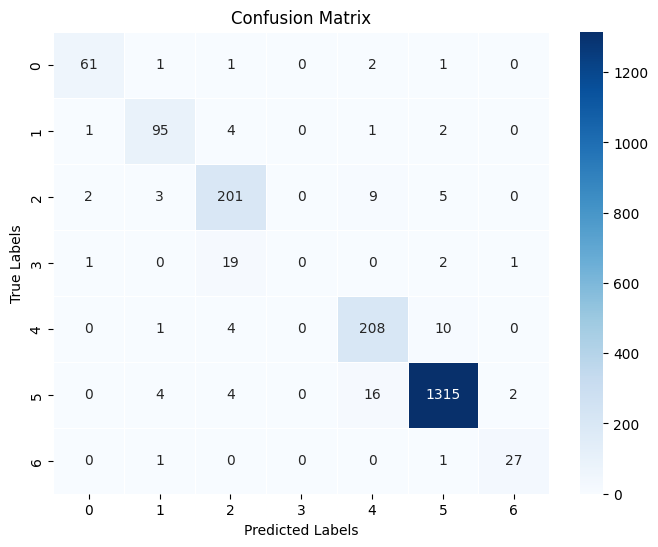


Multiclass ROC AUC Score: 0.9625


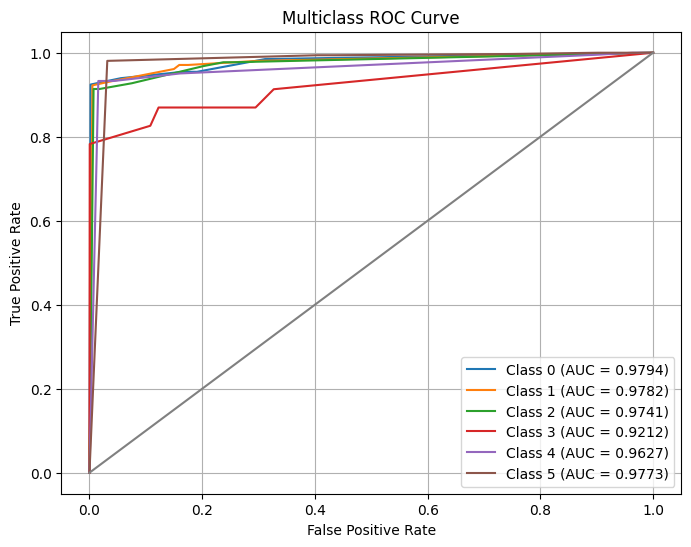

In [ ]:


# Load train and test predictions from all 6 models
model_paths = [
    "/content/drive/MyDrive/HAM10000/paper4/gnet/x_train_pred_gnet_ham.npy", "/content/drive/MyDrive/HAM10000/paper4/gnet/x_test_pred_gnet_ham.npy",
    "/content/drive/MyDrive/HAM10000/paper4/dnet/x_train_pred_dnet_ham.npy", "/content/drive/MyDrive/HAM10000/paper4/dnet/x_test_pred_dnet_ham.npy",
    "/content/drive/MyDrive/HAM10000/paper4/mnet/x_train_pred_mnet_ham.npy", "/content/drive/MyDrive/HAM10000/paper4/mnet/x_test_pred_mnet_ham.npy",
    "/content/drive/MyDrive/HAM10000/paper4/nnet/x_train_pred_nnet_ham.npy", "/content/drive/MyDrive/HAM10000/paper4/nnet/x_test_pred_nnet_ham.npy",
    "/content/drive/MyDrive/HAM10000/paper4/irnet/x_train_pred_irnet_ham.npy", "/content/drive/MyDrive/HAM10000/paper4/irnet/x_test_pred_irnet_ham.npy",
    "/content/drive/MyDrive/HAM10000/paper4/ccnngru/x_train_pred_ccnngru_ham.npy", "/content/drive/MyDrive/HAM10000/paper4/ccnngru/x_test_pred_ccnngru_ham.npy"

    ]

models = [np.load(path) for path in model_paths]

# Split into train & test sets
train_predictions = [models[i] for i in range(0, len(models), 2)]
test_predictions = [models[i] for i in range(1, len(models), 2)]

# Load true labels
y_train = np.load('/content/drive/MyDrive/HAM10000/paper4/dataset/y_train_f.npy')
y_test = np.load('/content/drive/MyDrive/HAM10000/paper4/dataset/y_test_f.npy')
y_train=np.argmax(y_train, axis=1)
y_test=np.argmax(y_test, axis=1)

# Get number of classes
# classes = np.unique(y_train)
# n_classes = len(classes)

# Find best combination of models
best_acc = 0
best_combination = None
best_svm = None

# Try all combinations of models (1 to 6 models combined)
for r in range(1, 7):
    for combo in combinations(range(6), r):
        # Stack selected models
        X_train = np.hstack([train_predictions[i].reshape(-1, 1) for i in combo])
        # print("\t X_train",X_train.shape)
        X_test = np.hstack([test_predictions[i].reshape(-1, 1) for i in combo])
        # print("\t X_test",X_test.shape)

        # Train SVM
        svm = SVC(kernel='linear', probability=True, decision_function_shape='ovr')  # One-vs-Rest (OvR) for multiclass
        svm.fit(X_train, y_test)

        # Evaluate accuracy
        y_pred = svm.predict(X_test)
        acc = accuracy_score(y_test, y_pred)

        print(f"Combination {combo}: Accuracy = {acc:.4f}")

        # Save the best model
        if acc > best_acc:
            best_acc = acc
            best_combination = combo
            best_svm = svm

print(f"\nBest Combination: {best_combination} with Accuracy = {best_acc:.4f}")


# Evaluate Best Model
X_test_best = np.hstack([test_predictions[i].reshape(-1, 1) for i in best_combination])

# Ensure 2D shape
if X_test_best.ndim == 1:
    X_test_best = X_test_best.reshape(-1, 1)  # Fix single-model issue

y_pred_best = best_svm.predict(X_test_best)
np.save("/content/drive/MyDrive/HAM10000/paper4/svm/x_test_pred_svm_ham.npy",y_pred_best)
y_prob_best = best_svm.predict_proba(X_test_best)
np.save("/content/drive/MyDrive/HAM10000/paper4/svm/x_test_prob_svm_ham.npy",y_prob_best)


# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_best)
print("\nConfusion Matrix:")
print(conf_matrix)

# Plot Confusion Matrix
# Compute confusion matrix (if not already computed)
conf_matrix = confusion_matrix(y_test, y_pred_best)
n_classes=6
# Plot Confusion Matrix with Values
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", linewidths=0.5, cbar=True)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Compute ROC AUC for Multiclass (One-vs-Rest)
classes = np.unique(y_test)  # Ensures classes are an array-like
# Binarize y_test for ROC AUC computation
y_test_bin = label_binarize(y_test, classes=classes)  # Binarize labels for multiclass AUC
roc_auc = roc_auc_score(y_test_bin, y_prob_best, multi_class='ovr')
print(f"\nMulticlass ROC AUC Score: {roc_auc:.4f}")

# Plot ROC Curve for each class
plt.figure(figsize=(8, 6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_best[:, i])
    plt.plot(fpr, tpr, label=f"Class {classes[i]} (AUC = {roc_auc_score(y_test_bin[:, i], y_prob_best[:, i]):.4f})")

plt.plot([0, 1], [0, 1], color='gray', linestyle='-')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve")
plt.legend()
plt.grid()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
# Full model name mapping
model_names = {
    'M1': 'GoogleNet',
    'M2': 'DenseNet201',
    'M3': 'MobileNetV2',
    'M4': 'NASNet',
    'M5': 'InceptionResNetV2',
    'M6': 'PHMBCNNGRU'

}
# Your dictionary
data = {

    2: {92.07, 89.33, 79.30, 80.20, 95.01, 90.67, 91.92, 91.72, 94.61, 88.88, 88.43, 95.01, 80.35, 94.96, 95.01},
    3: {91.07, 91.87, 91.62, 94.56, 88.33, 88.73, 94.91, 81.60, 95.06, 95.01, 92.22, 91.67, 95.01, 91.57, 94.46, 94.46, 89.48, 94.96, 94.91, 94.86},
    4:{91.32, 91.77, 94.76, 91.57, 94.66, 94.56, 89.48, 94.96, 94.96, 94.96, 92.27, 95.06, 95.01, 94.91, 94.86},
    5:{92.37, 95.06, 95.01, 94.71, 95.01, 95.10},
    6:{95.11}
}

# Convert to DataFrame
rows = []
for key, values in data.items():
    for val in values:
        rows.append({'Key': key, 'Value': val})

df = pd.DataFrame(rows)

# Find the max value
max_val = df['Value'].max()

# Add color column
df['Color'] = df['Value'].apply(lambda x: 'red' if x == max_val else 'skyblue')

# Plot
plt.figure(figsize=(10,5), dpi=300)
for i, row in df.iterrows():
    plt.scatter(row['Key'], row['Value'], color=row['Color'], s=75)
                # , edgecolor='black')
    if row['Color'] == 'red':
        plt.text(row['Key'], row['Value'] + 0.4, f"{{M1,M2,M3,M4,M5,M6}} = {row['Value']}%",
                 ha='right', va='bottom', fontsize=12, color='red')
# Set x-axis to show only unique keys
plt.xticks(sorted(data.keys()), fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(78, 96)
# Combined legend text box
legend_text = "Legend:\n• Best Combination (red dot)\n\nModel Names:\n" + '\n'.join([f"{k} = {v}" for k, v in model_names.items()])
plt.gcf().text(0.79, 0.15, legend_text, fontsize=8.5, va='bottom', bbox=dict(facecolor='white', edgecolor='gray'))

# Labels & layout
# plt.title('Strip Plot (Highlight Highest Value)')
plt.xlabel("Number of Models in Combination", fontsize=10)
plt.ylabel("Accuracy (%)", fontsize=10)
plt.title("SVM classifier Accuracy Visualization on Model Combinations", fontsize=12, weight='bold')
# plt.xlabel('Key')
# plt.ylabel('Value')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


#MLP

##feature extraction

In [ ]:
base_model = InceptionV3(weights="imagenet", include_top=False, pooling="avg")
X_train_gnet = base_model.predict(x_train)
X_test_gnet = base_model.predict(x_test)
np.save("/content/drive/MyDrive/HAM10000/paper4/mlp/X_train_gnet_features.npy",X_train_gnet)
np.save("/content/drive/MyDrive/HAM10000/paper4/mlp/X_test_gnet_features.npy",X_test_gnet)

base_model = DenseNet201(weights='imagenet', include_top=False, pooling='avg')
X_train_dnet = base_model.predict(x_train)
X_test_dnet = base_model.predict(x_test)
np.save("/content/drive/MyDrive/HAM10000/paper4/mlp/X_train_dnet_features.npy",X_train_dnet)
np.save("/content/drive/MyDrive/HAM10000/paper4/mlp/X_test_dnet_features.npy",X_test_dnet)

base_model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')
X_train_mnet = base_model.predict(x_train)
X_test_mnet = base_model.predict(x_test)
np.save("/content/drive/MyDrive/HAM10000/paper4/mlp/X_train_mnet_features.npy",X_train_mnet)
np.save("/content/drive/MyDrive/HAM10000/paper4/mlp/X_test_mnet_features.npy",X_test_mnet)

from tensorflow.keras.preprocessing.image import smart_resize

# Resize function
def resize_images(images, target_size=(224, 224)):
    resized_images = np.array([smart_resize(img, target_size) for img in images])
    return resized_images

# Resize x_train and x_test
x_train_resized = resize_images(x_train)  # Shape becomes (4000, 224, 224, 3)
x_test_resized = resize_images(x_test)
base_model = NASNetMobile(weights='imagenet',
                          include_top=False, pooling='avg')
X_train_nnet = base_model.predict(x_train_resized)
X_test_nnet = base_model.predict(x_test_resized )
np.save("/content/drive/MyDrive/HAM10000/paper4/mlp/X_train_nnet_features.npy",X_train_nnet)
np.save("/content/drive/MyDrive/HAM10000/paper4/mlp/X_test_nnet_features.npy",X_test_nnet)




1174/1174 ━━━━━━━━━━━━━━━━━━━━ 33s 20ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step
74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 83s 50ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 19s 312ms/step


<ipython-input-7-2e2336b23ae0>:13: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 29s 17ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 113ms/step
19993432/19993432 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 63s 38ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 175ms/step
219055592/219055592 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step


In [ ]:
base_model = InceptionResNetV2(weights='imagenet', include_top=False, pooling='avg')
X_train_irnet = base_model.predict(x_train)
X_test_irnet = base_model.predict(x_test)
np.save("/content/drive/MyDrive/HAM10000/paper4/mlp/X_train_irnet_features.npy",X_train_irnet)
np.save("/content/drive/MyDrive/HAM10000/paper4/mlp/X_test_irnet_features.npy",X_test_irnet)

# with GRU
def residual_block(x, filters, y=None):
    if y is None:
        y = x  # Set y to x if y is not provided
    shortcut = y
    x = Conv2D(filters, (3, 3), padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = ELU()(x)
    x = Conv2D(filters, (3, 3), padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    return Add()([x, shortcut])

# Xception Block
def xception_block(x, filters):
    for _ in range(3):
        x = layers.SeparableConv2D(filters, (3, 3), padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.ELU()(x)
    return x

# Squeeze-Excite Block
def squeeze_excite_block(x, ratio=16):
    filters = x.shape[-1]
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(filters // ratio, activation='elu')(se)
    se = layers.Dense(filters, activation='sigmoid')(se)
    return layers.multiply([x, se])

# MBConv Block (MobileNetV2)
def mbconv_block(x, filters, expansion_factor=6):
    input_filters = x.shape[-1]
    expanded_filters = input_filters * expansion_factor
    x = layers.Conv2D(expanded_filters, (1, 1), padding='same', activation='elu')(x)
    x = layers.DepthwiseConv2D((3, 3), padding='same')(x)
    x = layers.Conv2D(filters, (1, 1), padding='same', activation='linear')(x)
    return x

# Ghost Block
def ghost_block(x, filters):
    primary = layers.Conv2D(filters // 2, (1, 1), padding='same')(x)
    cheap_operation = layers.DepthwiseConv2D((3, 3), padding='same')(primary)
    return layers.concatenate([primary, cheap_operation])

# Fire Block (SqueezeNet)
def fire_block(x, squeeze_filters, expand_filters):
    x = layers.Conv2D(squeeze_filters, (1, 1), activation='elu')(x)
    expand1x1 = layers.Conv2D(expand_filters, (1, 1), activation='elu')(x)
    expand3x3 = layers.Conv2D(expand_filters, (3, 3), padding='same', activation='elu')(x)
    return layers.concatenate([expand1x1, expand3x3])

# Depthwise Separable Convolution Block
def dsc_block(x, filters):
    x = layers.SeparableConv2D(filters, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ELU()(x)
    return x

# Build the full model
def build_model(input_shape=(224, 224, 3), num_classes=6):
    inputs = layers.Input(shape=input_shape)

    # Initial Convolution and Pooling
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x32 = layers.MaxPooling2D(pool_size=(2, 2))(x)  # Shape: (64, 64, 32)

    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x32)
    x = layers.BatchNormalization()(x)
    x64 = layers.MaxPooling2D(pool_size=(2, 2))(x)  # Shape: (32, 32, 64)

    x = layers.Conv2D(256, (3, 3), padding='same', activation='relu')(x64)
    x = layers.BatchNormalization()(x)
    x128 = layers.MaxPooling2D(pool_size=(2, 2))(x)  # Shape: (16, 16, 128)

    x = layers.Conv2D(256, (3, 3), padding='same', activation='relu')(x128)
    x = layers.BatchNormalization()(x)
    x256 = layers.MaxPooling2D(pool_size=(2, 2))(x)  # Shape: (08, 08, 256)

    # Block 1: Residual + MBConv + Depthwise Separable Convolution
    x1 = residual_block(x32, 32)
    x1 = SeparableConv2D(32, (3, 3), padding='same',
                    depthwise_regularizer=l2(0.01),
                    pointwise_regularizer=l2(0.01))(x1)
    x1 = mbconv_block(x1, 32)
    mbconv1 = Conv2D(64,(3,3),padding="same")(x1)
    mbconv1 = layers.MaxPooling2D(pool_size=(2, 2))(mbconv1)
    x1 = SeparableConv2D(32, (3, 3), padding='same',
                    depthwise_regularizer=l2(0.01),
                    pointwise_regularizer=l2(0.01))(x1)
    x1 = dsc_block(x1,32)
    x1 = Conv2D(256, (3, 3), padding='same')(x1)
    x1 = BatchNormalization()(x1)
    x1 = layers.ReLU()(x1)

    # Block 2: Xception + res + dsc
    x2 = xception_block(x64, 64)
    x2 = SeparableConv2D(64, (3, 3), padding='same',
                    depthwise_regularizer=l2(0.01),
                    pointwise_regularizer=l2(0.01))(x2)
    x2 = residual_block(x2, 64,mbconv1)
    x2 = SeparableConv2D(64, (3, 3), padding='same',
                    depthwise_regularizer=l2(0.01),
                    pointwise_regularizer=l2(0.01))(x2)
    x2 = mbconv_block(x2, 64)
    x2 = Conv2D(256, (3, 3), padding='same')(x2)
    x2 = BatchNormalization()(x2)
    x2 = layers.ReLU()(x2)

    # Block 3: SE + MBConv + Depthwise Separable Convolution
    x3 = squeeze_excite_block(x128)
    x3 = SeparableConv2D(128, (3, 3), padding='same',
                    depthwise_regularizer=l2(0.01),
                    pointwise_regularizer=l2(0.01))(x3)
    x3 = mbconv_block(x3, 128)
    mbconv3 = Conv2D(256,(3,3),padding="same")(x3)
    mbconv3 = layers.MaxPooling2D(pool_size=(2, 2))(mbconv3)
    x3 = SeparableConv2D(128, (3, 3), padding='same',
                    depthwise_regularizer=l2(0.01),
                    pointwise_regularizer=l2(0.01))(x3)
    x3 = dsc_block(x3, 128)
    x3 = Conv2D(256, (3, 3), padding='same')(x3)
    x3 = BatchNormalization()(x3)
    x3 = layers.ReLU()(x3)

    # Block 4: MBConv + Residual + Depthwise Separable Convolution
    x4 = mbconv_block(x256, 256)
    x4 = SeparableConv2D(256, (3, 3), padding='same',
                    depthwise_regularizer=l2(0.01),
                    pointwise_regularizer=l2(0.01))(x4)
    x4 = residual_block(x4, 256,mbconv3)
    x4 = SeparableConv2D(256, (3, 3), padding='same',
                    depthwise_regularizer=l2(0.01),
                    pointwise_regularizer=l2(0.01))(x4)
    x4 = dsc_block(x4, 256)
    x4 = Conv2D(256, (3, 3), padding='same')(x4)
    x4 = BatchNormalization()(x4)
    x4 = layers.ReLU()(x4)

    # Concatenate all blocks
    x1=layers.MaxPooling2D(pool_size=(2, 2))(x1)
    x1=layers.MaxPooling2D(pool_size=(2, 2))(x1)
    x1=layers.MaxPooling2D(pool_size=(2, 2))(x1)
    x2=layers.MaxPooling2D(pool_size=(2, 2))(x2)
    x2=layers.MaxPooling2D(pool_size=(2, 2))(x2)
    x3=layers.MaxPooling2D(pool_size=(2, 2))(x3)
    concatenated = layers.concatenate([x1, x2, x3, x4], axis=-1)

    x = SeparableConv2D(1024, (3, 3), padding='same')(concatenated)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SeparableConv2D(1024, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)


    # Classifier
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    # x = layers.Dropout(0.5)(x)
    x = Reshape((-1,512))(x)
    gru = GRU(512)(x)
    x = layers.Dense(512, activation='relu')(gru)
    # x = layers.Dropout(0.5)(x)
    # outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, x)
    return model
model = build_model()
X_train_ccnngru = model.predict(x_train)
X_test_ccnngru = model.predict(x_test)
np.save("/content/drive/MyDrive/HAM10000/paper4/mlp/X_train_ccnngru_features.npy",X_train_ccnngru)
np.save("/content/drive/MyDrive/HAM10000/paper4/mlp/X_test_ccnngru_features.npy",X_test_ccnngru)





1174/1174 ━━━━━━━━━━━━━━━━━━━━ 60s 40ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 129ms/step
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step


NameError: name 'X_train_gnet' is not defined

In [ ]:
X_train_gnet=np.load('/content/drive/MyDrive/HAM10000/paper4/mlp/X_train_gnet_features.npy')
X_test_gnet=np.load('/content/drive/MyDrive/HAM10000/paper4/mlp/X_test_gnet_features.npy')
X_train_dnet=np.load('/content/drive/MyDrive/HAM10000/paper4/mlp/X_train_dnet_features.npy')
X_test_dnet=np.load('/content/drive/MyDrive/HAM10000/paper4/mlp/X_test_dnet_features.npy')
X_train_mnet=np.load('/content/drive/MyDrive/HAM10000/paper4/mlp/X_train_mnet_features.npy')
X_test_mnet=np.load('/content/drive/MyDrive/HAM10000/paper4/mlp/X_test_mnet_features.npy')
X_train_nnet=np.load('/content/drive/MyDrive/HAM10000/paper4/mlp/X_train_nnet_features.npy')
X_test_nnet=np.load('/content/drive/MyDrive/HAM10000/paper4/mlp/X_test_nnet_features.npy')
X_train_irnet=np.load('/content/drive/MyDrive/HAM10000/paper4/mlp/X_train_irnet_features.npy')
X_test_irnet=np.load('/content/drive/MyDrive/HAM10000/paper4/mlp/X_test_irnet_features.npy')
X_train_ccnngru=np.load('/content/drive/MyDrive/HAM10000/paper4/mlp/X_train_ccnngru_features.npy')
X_test_ccnngru=np.load('/content/drive/MyDrive/HAM10000/paper4/mlp/X_test_ccnngru_features.npy')
# Concatenate Features
x_train_features = np.hstack((X_train_gnet,X_train_mnet,X_train_nnet,X_train_dnet,X_train_irnet,X_train_ccnngru))
x_test_features = np.hstack((X_test_gnet,X_test_mnet,X_test_nnet,X_test_dnet,X_test_irnet,X_test_ccnngru))
print("x_train_feature_shape",x_train_features.shape)
print("x_test_feature_shape",x_test_features.shape)
# Print total features after concatenation
print(f"Total features after concatenation: {x_train_features.shape[1]}")

x_train_feature_shape (37548, 8352)
x_test_feature_shape (2005, 8352)
Total features after concatenation: 8352


##on all features-82.99

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


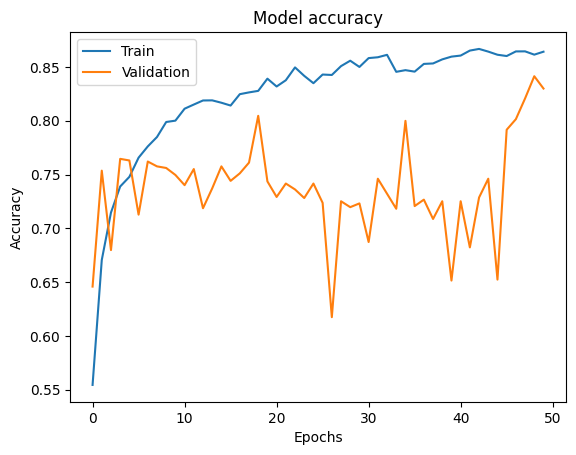

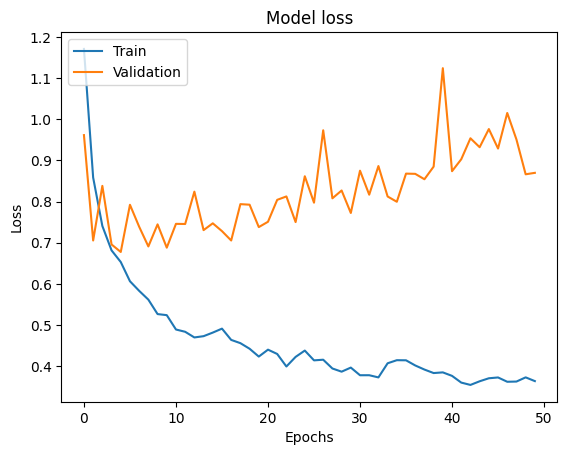

Confusion Matrix:
[[  45    4   12    0    0    5    0]
 [   0   85    4    0    0   14    0]
 [   2   12  179    0    1   25    1]
 [   0    4    2   12    0    5    0]
 [   1   11   44    0  104   63    0]
 [   0   23   86    0   20 1211    1]
 [   0    0    0    0    0    1   28]]


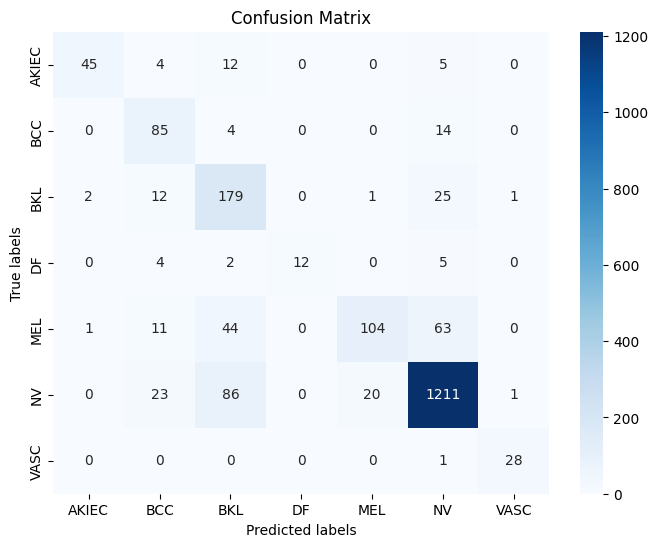


Classification Report:
              precision    recall  f1-score   support

           0     0.9375    0.6818    0.7895        66
           1     0.6115    0.8252    0.7025       103
           2     0.5474    0.8136    0.6545       220
           3     1.0000    0.5217    0.6857        23
           4     0.8320    0.4664    0.5977       223
           5     0.9147    0.9031    0.9088      1341
           6     0.9333    0.9655    0.9492        29

    accuracy                         0.8299      2005
   macro avg     0.8252    0.7396    0.7554      2005
weighted avg     0.8516    0.8299    0.8298      2005



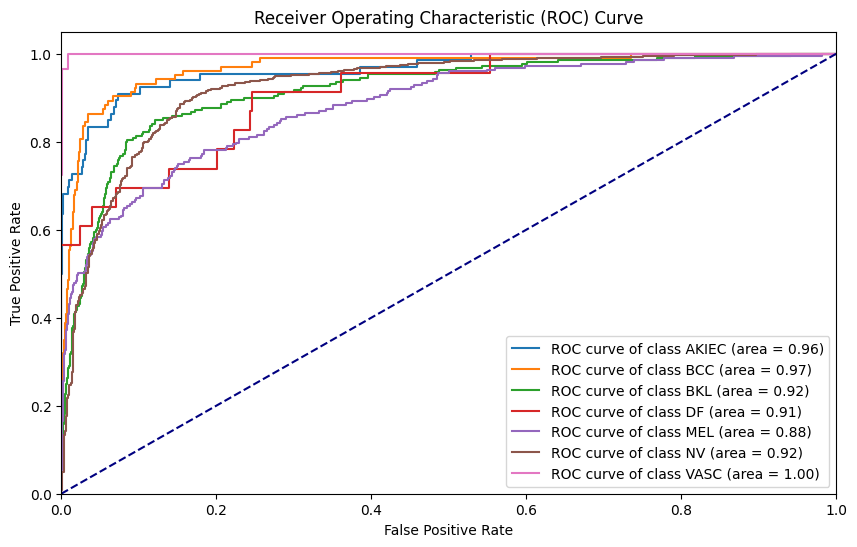

AUC: 0.924
AUC: 0.938


In [ ]:
y_train = np.load('/content/drive/MyDrive/HAM10000/paper4/dataset/y_train_f.npy')
y_test = np.load('/content/drive/MyDrive/HAM10000/paper4/dataset/y_test_f.npy')

model = Sequential([
    Dense(512, activation='relu', input_shape=(8352,)),  # Match input shape of selected features
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(7, activation='softmax')  # Multi-class classification (6 classes)
])

# Compile Model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train Model
history = model.fit(x_train_features, y_train, epochs=50, batch_size=32, validation_data=(x_test_features,y_test),verbose=0)
#plt.figure(figsize=(12, 5))
# Plot Accuracy
# plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')

# Plot Loss
# plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Loss')

plt.show()

# ---------------------- Model Evaluation ------------------------
y_pred_probs = model.predict(x_test_features)  # Get prediction probabilities
y_pred = np.argmax(y_pred_probs, axis=1)  # Convert to class labels
np.save("/content/drive/MyDrive/HAM10000/paper4/mlp/x_test_prob_allfeatures_ham.npy",y_pred_probs)
np.save("/content/drive/MyDrive/HAM10000/paper4/mlp/x_test_pred_allfeatures_ham.npy",y_pred)# Convert one-hot encoded y_test to class labels
y_test_labels = np.argmax(y_test, axis=1)

# Convert softmax probabilities to predicted class labels
y_pred_labels = np.argmax(y_pred_probs, axis=1)

# Generate classification report
print("\nClassification Report:\n", classification_report(y_test_labels, y_pred_labels))

# ---------------------- Colorful Confusion Matrix ------------------------
cm = confusion_matrix(y_test_labels, y_pred_labels)
plt.figure(figsize=(8,6))
num_classes=7
sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm", xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# ---------------------- AUC & ROC Curve ------------------------
y_true=np.argmax(y_test,axis=1)
y_true_binary = label_binarize(y_true, classes=np.unique(y_true))
n_classes = y_true_binary.shape[1]
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    # fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs.iloc[:, i])
    fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
# Plot ROC curve
plt.figure(figsize=(10, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label='ROC curve of class {0} (area = {1:0.2f})'.format(class_names[i], roc_auc[i]), linestyle='-')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()
auc1 = roc_auc_score(y_true, y_pred_probs,multi_class='ovo')
print('AUC: %.3f' % auc1)
auc2 = roc_auc_score(y_true, y_pred_probs,multi_class='ovr')
print('AUC: %.3f' % auc2)


##PCA--92.97 features 3171

In [ ]:
X_train_gnet=np.load('/content/drive/MyDrive/HAM10000/paper4/mlp/X_train_gnet_features.npy')
X_test_gnet=np.load('/content/drive/MyDrive/HAM10000/paper4/mlp/X_test_gnet_features.npy')
X_train_dnet=np.load('/content/drive/MyDrive/HAM10000/paper4/mlp/X_train_dnet_features.npy')
X_test_dnet=np.load('/content/drive/MyDrive/HAM10000/paper4/mlp/X_test_dnet_features.npy')
X_train_mnet=np.load('/content/drive/MyDrive/HAM10000/paper4/mlp/X_train_mnet_features.npy')
X_test_mnet=np.load('/content/drive/MyDrive/HAM10000/paper4/mlp/X_test_mnet_features.npy')
X_train_nnet=np.load('/content/drive/MyDrive/HAM10000/paper4/mlp/X_train_nnet_features.npy')
X_test_nnet=np.load('/content/drive/MyDrive/HAM10000/paper4/mlp/X_test_nnet_features.npy')
X_train_irnet=np.load('/content/drive/MyDrive/HAM10000/paper4/mlp/X_train_irnet_features.npy')
X_test_irnet=np.load('/content/drive/MyDrive/HAM10000/paper4/mlp/X_test_irnet_features.npy')
X_train_ccnngru=np.load('/content/drive/MyDrive/HAM10000/paper4/mlp/X_train_ccnngru_features.npy')
X_test_ccnngru=np.load('/content/drive/MyDrive/HAM10000/paper4/mlp/X_test_ccnngru_features.npy')

# Concatenate Features
x_train_features = np.hstack((X_train_gnet,X_train_mnet,X_train_nnet,X_train_dnet,X_train_irnet,X_train_ccnngru))
x_test_features = np.hstack((X_test_gnet,X_test_mnet,X_test_nnet,X_test_dnet,X_test_irnet,X_test_ccnngru))
print("x_train_feature_shape",x_train_features.shape)
print("x_test_feature_shape",x_test_features.shape)
# Print total features after concatenation
print(f"Total features after concatenation: {x_train_features.shape[1]}")

x_train_feature_shape (37548, 8352)
x_test_feature_shape (2005, 8352)
Total features after concatenation: 8352


In [ ]:
y_train = np.load('/content/drive/MyDrive/HAM10000/paper4/dataset/y_train_f.npy')
y_test = np.load('/content/drive/MyDrive/HAM10000/paper4/dataset/y_test_f.npy')


# Apply PCA for Dimensionality Reduction (Retain 99% Variance)
pca = PCA(n_components=0.99)
x_train_features_pca = pca.fit_transform(x_train_features)
x_test_features_pca = pca.transform(x_test_features)

print(f"Total features after PCA: {x_train_features_pca.shape[1]}")
print("x_train_features_pca",x_train_features_pca.shape)
print("x_test_features_pca",x_test_features_pca.shape)
# print("y_train",y_train.shape)
# print("y_test",y_test.shape)

# y_train_onehot=np.argmax(y_train,axis=1)
# y_test_onehot=np.argmax(y_test,axis=1)
# print("Shape of y_train_onehot:", y_train_onehot.shape)  # Should be (N, num_classes)
# print("Shape of y_test_onehot:", y_test_onehot.shape)

model = Sequential([
    Dense(512, activation='relu', input_shape=(3171,)),  # Match input shape of selected features
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(7, activation='softmax')  # Multi-class classification (6 classes)
])

# Compile Model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train Model
history = model.fit(x_train_features_pca, y_train, epochs=50, batch_size=32, validation_data=(x_test_features_pca,y_test), verbose=0)

# plt.figure(figsize=(12, 5))
# Plot Accuracy
# plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')

# Plot Loss
# plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Loss')
plt.show()

# ---------------------- Model Evaluation ------------------------
y_pred_probs = model.predict(x_test_features_pca)  # Get prediction probabilities
y_pred = np.argmax(y_pred_probs, axis=1)  # Convert to class labels
np.save("/content/drive/MyDrive/HAM10000/paper4/mlp/x_test_prob_pca_ham.npy",y_pred_probs)
np.save("/content/drive/MyDrive/HAM10000/paper4/mlp/x_test_pred_pca_ham.npy",y_pred)
# Convert one-hot encoded y_test to class labels
y_test_labels = np.argmax(y_test, axis=1)  # Converts (461,6) → (461,)

# Convert softmax probabilities to predicted class labels
y_pred_labels = np.argmax(y_pred_probs, axis=1)  # Converts (461,6) → (461,)

# Generate classification report
print("\nClassification Report:\n", classification_report(y_test_labels, y_pred_labels))

# ---------------------- Colorful Confusion Matrix ------------------------
cm = confusion_matrix(y_test_labels, y_pred_labels)
plt.figure(figsize=(8,6))
num_classes=7
sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm", xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# ---------------------- AUC & ROC Curve ------------------------
y_true=np.argmax(y_test,axis=1)
y_true_binary = label_binarize(y_true, classes=np.unique(y_true))
n_classes = y_true_binary.shape[1]
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    # fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs.iloc[:, i])
    fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
# Plot ROC curve
plt.figure(figsize=(10, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label='ROC curve of class {0} (area = {1:0.2f})'.format(class_names[i], roc_auc[i]), linestyle='-')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()
auc1 = roc_auc_score(y_true, y_pred_probs,multi_class='ovo')
print('AUC: %.3f' % auc1)
auc2 = roc_auc_score(y_true, y_pred_probs,multi_class='ovr')
print('AUC: %.3f' % auc2)


##MI

###K=500--87.33

Shape of y_train_onehot: (37548,)
Shape of y_test_onehot: (2005,)
Original Shape: (37548, 224, 224, 3)
Reduced Shape: (37548, 500)
Original Shape: (2005, 224, 224, 3)
Reduced Shape: (2005, 500)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


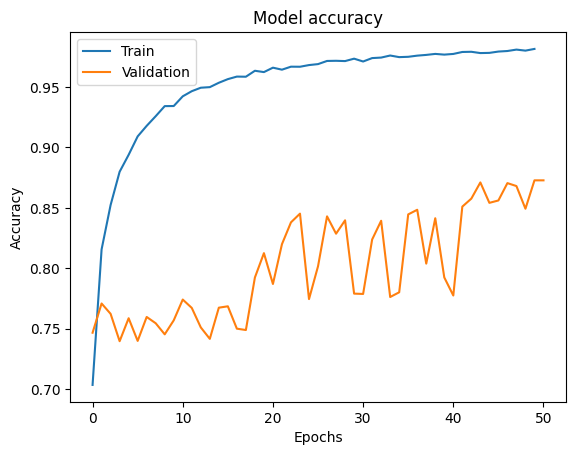

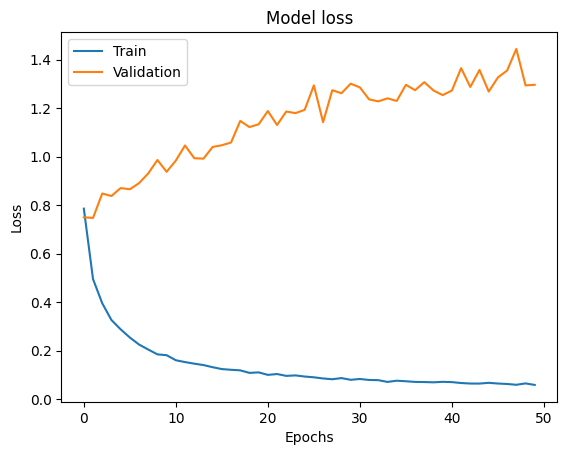

Confusion Matrix:
[[  52    5    2    0    2    5    0]
 [   2   81    2    6    4    7    1]
 [   7    7  170    2    8   26    0]
 [   0    0    1   19    1    2    0]
 [   3    4   15    0  163   38    0]
 [   5   14   23    6   54 1238    1]
 [   0    0    0    0    0    1   28]]


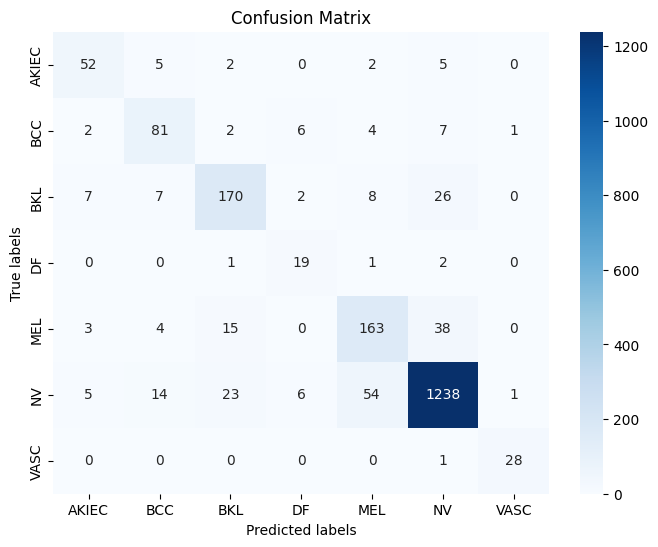


Classification Report:
              precision    recall  f1-score   support

           0     0.7536    0.7879    0.7704        66
           1     0.7297    0.7864    0.7570       103
           2     0.7981    0.7727    0.7852       220
           3     0.5758    0.8261    0.6786        23
           4     0.7026    0.7309    0.7165       223
           5     0.9400    0.9232    0.9315      1341
           6     0.9333    0.9655    0.9492        29

    accuracy                         0.8733      2005
   macro avg     0.7762    0.8275    0.7983      2005
weighted avg     0.8768    0.8733    0.8746      2005



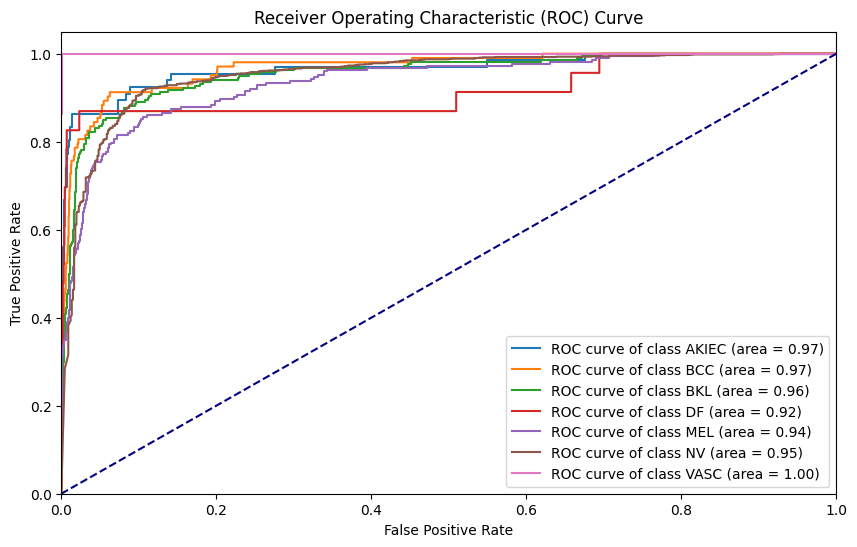

AUC: 0.949
AUC: 0.956


In [ ]:
y_train = np.load('/content/drive/MyDrive/HAM10000/paper4/dataset/y_train_f.npy')
y_test = np.load('/content/drive/MyDrive/HAM10000/paper4/dataset/y_test_f.npy')
y_train_onehot=np.argmax(y_train,axis=1)
y_test_onehot=np.argmax(y_test,axis=1)
print("Shape of y_train_onehot:", y_train_onehot.shape)  # Should be (N, num_classes)
print("Shape of y_test_onehot:", y_test_onehot.shape)

from sklearn.feature_selection import mutual_info_classif
# Compute Mutual Information Scores
mi_scores = mutual_info_classif(x_train_features_pca, y_train_onehot)

# Get Top-K Important Features (e.g., Select 1000 Best Features)
top_k = 500
selected_features_idx = np.argsort(mi_scores)[-top_k:]  # Indices of top features
X_train_selected_mi = x_train_features_pca[:, selected_features_idx]  # Select top features

# Print new shape after feature selection
print("Original Shape:", x_train.shape)  # (4000, 4146)
print("Reduced Shape:", X_train_selected_mi.shape)  # (4000, 1000)

X_test_selected_mi = x_test_features_pca[:, selected_features_idx]  # Select top features

# Print new shape after feature selection
print("Original Shape:", x_test.shape)  # (4000, 4146)
print("Reduced Shape:", X_test_selected_mi.shape)  # (4000, 1000)

# Define MLP Model
model = Sequential([
    Dense(512, activation='relu', input_shape=(500,)),  # Match input shape of selected features
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(7, activation='softmax')  # Multi-class classification (6 classes)
])

# Compile Model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train Model
history = model.fit(X_train_selected_mi, y_train, epochs=50, batch_size=32, validation_data=(X_test_selected_mi, y_test),verbose=0)
# Evaluate on Test Data
# test_loss, test_acc = model.evaluate(x_test_features_pca, y_test)
# print(f"Test Accuracy: {test_acc:.4f}")


# ---------------------- Plot Accuracy & Loss ------------------------
# plt.figure(figsize=(12, 5))

# Plot Accuracy
# plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')

# Plot Loss
# plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Loss')

plt.show()

# # ---------------------- Model Evaluation ------------------------
y_pred_probs = model.predict(X_test_selected_mi)  # Get prediction probabilities
np.save("/content/drive/MyDrive/HAM10000/paper4/mlp/x_test_prob_k500_ham.npy",y_pred_probs)
y_pred = np.argmax(y_pred_probs, axis=1)  # Convert to class labels
np.save("/content/drive/MyDrive/HAM10000/paper4/mlp/x_test_pred_k500_ham.npy",y_pred)


# Convert one-hot encoded y_test to class labels
y_test_labels = np.argmax(y_test, axis=1)  # Converts (461,6) → (461,)

# Convert softmax probabilities to predicted class labels
y_pred_labels = np.argmax(y_pred_probs, axis=1)  # Converts (461,6) → (461,)

# Generate classification report
print("\nClassification Report:\n", classification_report(y_test_labels, y_pred_labels))

# ---------------------- Colorful Confusion Matrix ------------------------
cm = confusion_matrix(y_test_labels, y_pred_labels)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm", xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# ---------------------- AUC & ROC Curve ------------------------
# Ensure y_test is one-hot encoded
y_true=np.argmax(y_test,axis=1)
y_true_binary = label_binarize(y_true, classes=np.unique(y_true))
n_classes = y_true_binary.shape[1]
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    # fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs.iloc[:, i])
    fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
# Plot ROC curve
plt.figure(figsize=(10, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label='ROC curve of class {0} (area = {1:0.2f})'.format(class_names[i], roc_auc[i]), linestyle='-')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()
auc1 = roc_auc_score(y_true, y_pred_probs,multi_class='ovo')
print('AUC: %.3f' % auc1)
auc2 = roc_auc_score(y_true, y_pred_probs,multi_class='ovr')
print('AUC: %.3f' % auc2)


###K=1000--91.97

Shape of y_train_onehot: (37548,)
Shape of y_test_onehot: (2005,)
Original Shape: (37548, 224, 224, 3)
Reduced Shape: (37548, 1000)
Original Shape: (2005, 224, 224, 3)
Reduced Shape: (2005, 1000)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


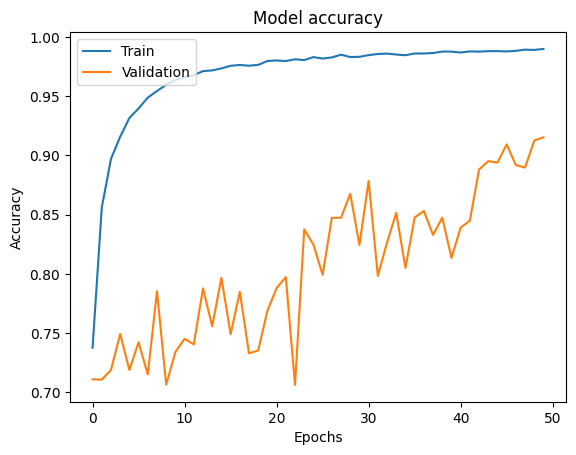

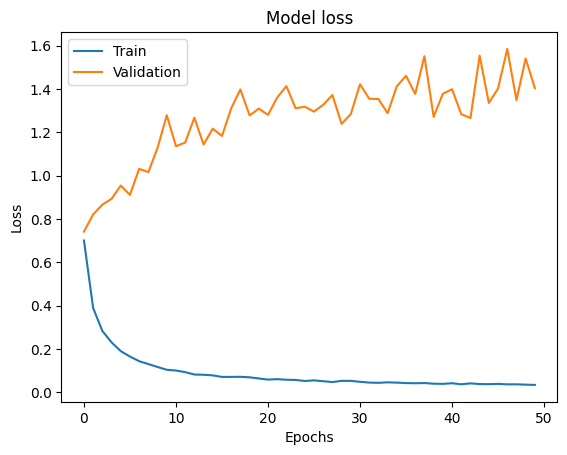

Confusion Matrix:
[[  59    1    3    0    0    3    0]
 [   3   91    0    0    1    7    1]
 [   9    3  175    0    6   27    0]
 [   1    0    0   17    1    4    0]
 [   4    4    3    0  184   28    0]
 [   4    3    9    1   33 1290    1]
 [   0    0    0    0    0    1   28]]


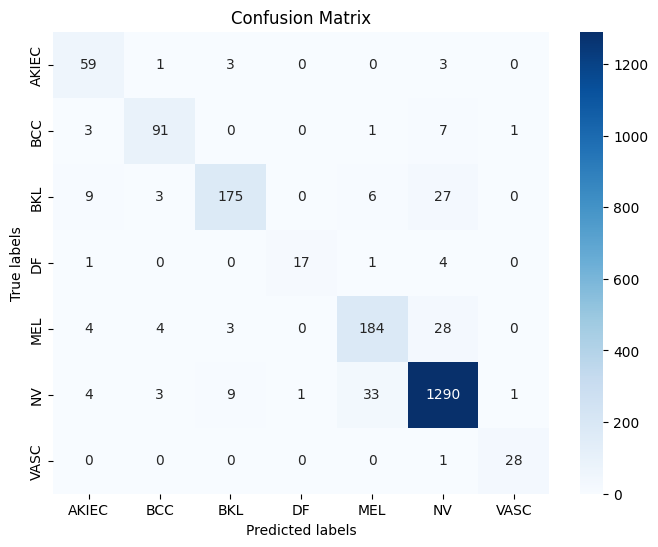


Classification Report:
              precision    recall  f1-score   support

           0     0.7375    0.8939    0.8082        66
           1     0.8922    0.8835    0.8878       103
           2     0.9211    0.7955    0.8537       220
           3     0.9444    0.7391    0.8293        23
           4     0.8178    0.8251    0.8214       223
           5     0.9485    0.9620    0.9552      1341
           6     0.9333    0.9655    0.9492        29

    accuracy                         0.9197      2005
   macro avg     0.8850    0.8664    0.8721      2005
weighted avg     0.9209    0.9197    0.9193      2005



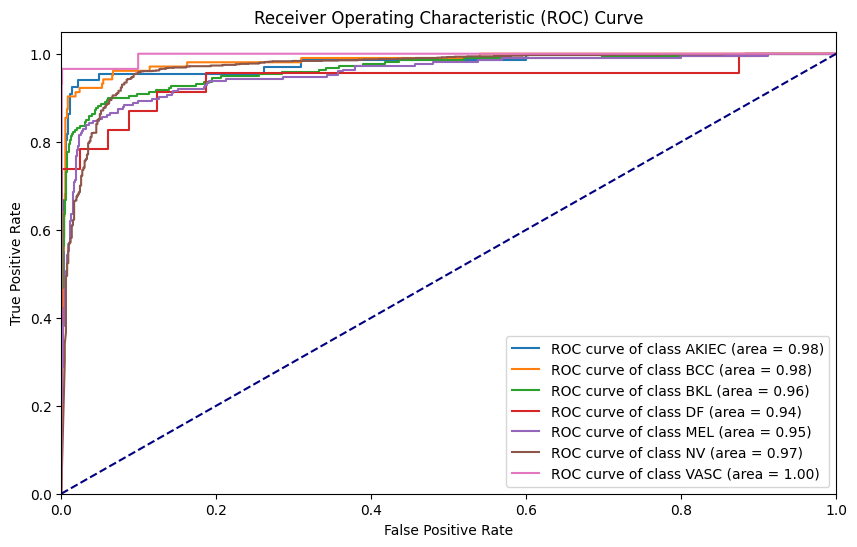

AUC: 0.962
AUC: 0.970


In [ ]:
y_train = np.load('/content/drive/MyDrive/HAM10000/paper4/dataset/y_train_f.npy')
y_test = np.load('/content/drive/MyDrive/HAM10000/paper4/dataset/y_test_f.npy')
y_train_onehot=np.argmax(y_train,axis=1)
y_test_onehot=np.argmax(y_test,axis=1)
print("Shape of y_train_onehot:", y_train_onehot.shape)  # Should be (N, num_classes)
print("Shape of y_test_onehot:", y_test_onehot.shape)

from sklearn.feature_selection import mutual_info_classif
# Compute Mutual Information Scores
mi_scores = mutual_info_classif(x_train_features_pca, y_train_onehot)

# Get Top-K Important Features (e.g., Select 1000 Best Features)
top_k = 1000
selected_features_idx = np.argsort(mi_scores)[-top_k:]  # Indices of top features
X_train_selected_mi = x_train_features_pca[:, selected_features_idx]  # Select top features

# Print new shape after feature selection
print("Original Shape:", x_train.shape)  # (4000, 4146)
print("Reduced Shape:", X_train_selected_mi.shape)  # (4000, 1000)

X_test_selected_mi = x_test_features_pca[:, selected_features_idx]  # Select top features

# Print new shape after feature selection
print("Original Shape:", x_test.shape)  # (4000, 4146)
print("Reduced Shape:", X_test_selected_mi.shape)  # (4000, 1000)

# Define MLP Model
model = Sequential([
    Dense(512, activation='relu', input_shape=(1000,)),  # Match input shape of selected features
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(7, activation='softmax')  # Multi-class classification (6 classes)
])

# Compile Model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train Model
history = model.fit(X_train_selected_mi, y_train, epochs=50, batch_size=32, validation_data=(X_test_selected_mi, y_test),verbose=0)
# Evaluate on Test Data
# test_loss, test_acc = model.evaluate(x_test_features_pca, y_test)
# print(f"Test Accuracy: {test_acc:.4f}")


# ---------------------- Plot Accuracy & Loss ------------------------
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Loss')

plt.show()

# # ---------------------- Model Evaluation ------------------------
y_pred_probs = model.predict(X_test_selected_mi)  # Get prediction probabilities
np.save("/content/drive/MyDrive/HAM10000/paper4/mlp/x_test_prob_k1000_ham.npy",y_pred_probs)
y_pred = np.argmax(y_pred_probs, axis=1)  # Convert to class labels
np.save("/content/drive/MyDrive/HAM10000/paper4/mlp/x_test_pred_K1000_ham.npy",y_pred)


# Convert one-hot encoded y_test to class labels
y_test_labels = np.argmax(y_test, axis=1)  # Converts (461,6) → (461,)

# Convert softmax probabilities to predicted class labels
y_pred_labels = np.argmax(y_pred_probs, axis=1)  # Converts (461,6) → (461,)

# Generate classification report
print("\nClassification Report:\n", classification_report(y_test_labels, y_pred_labels))

# ---------------------- Colorful Confusion Matrix ------------------------
cm = confusion_matrix(y_test_labels, y_pred_labels)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm", xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# # ---------------------- AUC & ROC Curve ------------------------
y_true=np.argmax(y_test,axis=1)
y_true_binary = label_binarize(y_true, classes=np.unique(y_true))
n_classes = y_true_binary.shape[1]
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    # fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs.iloc[:, i])
    fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
# Plot ROC curve
plt.figure(figsize=(10, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label='ROC curve of class {0} (area = {1:0.2f})'.format(class_names[i], roc_auc[i]), linestyle='-')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()
auc1 = roc_auc_score(y_true, y_pred_probs,multi_class='ovo')
print('AUC: %.3f' % auc1)
auc2 = roc_auc_score(y_true, y_pred_probs,multi_class='ovr')
print('AUC: %.3f' % auc2)



###K=1500--92.97

Shape of y_train_onehot: (37548,)
Shape of y_test_onehot: (2005,)
Original Shape: (37548, 224, 224, 3)
Reduced Shape: (37548, 1500)
Original Shape: (2005, 224, 224, 3)
Reduced Shape: (2005, 1500)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


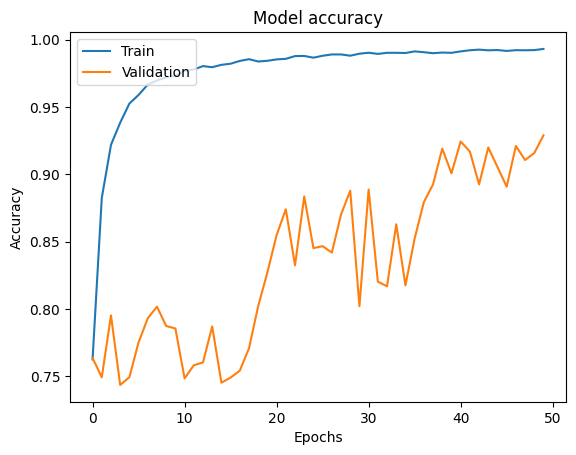

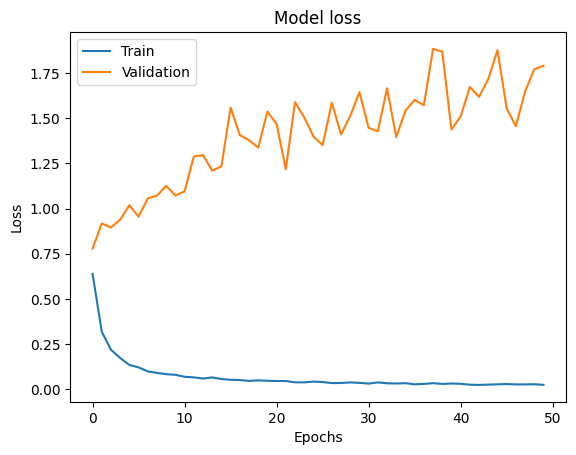

Confusion Matrix:
[[  56    4    4    0    0    2    0]
 [   1   91    1    1    2    7    0]
 [   3    6  176    0    1   34    0]
 [   0    0    0   22    0    1    0]
 [   2    4    6    0  178   33    0]
 [   1    7    4    0   16 1313    0]
 [   0    0    0    0    0    1   28]]


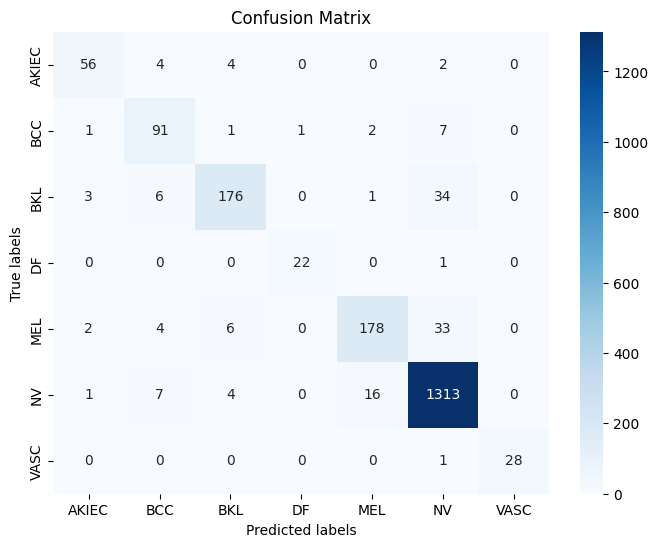


Classification Report:
              precision    recall  f1-score   support

           0     0.8889    0.8485    0.8682        66
           1     0.8125    0.8835    0.8465       103
           2     0.9215    0.8000    0.8564       220
           3     0.9565    0.9565    0.9565        23
           4     0.9036    0.7982    0.8476       223
           5     0.9439    0.9791    0.9612      1341
           6     1.0000    0.9655    0.9825        29

    accuracy                         0.9297      2005
   macro avg     0.9181    0.8902    0.9027      2005
weighted avg     0.9294    0.9297    0.9284      2005



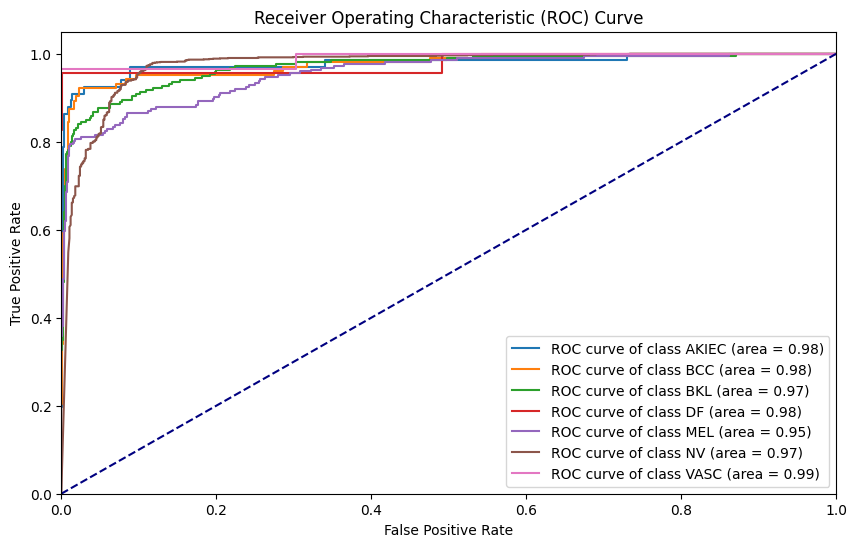

AUC: 0.965
AUC: 0.974


In [ ]:
y_train = np.load('/content/drive/MyDrive/HAM10000/paper4/dataset/y_train_f.npy')
y_test = np.load('/content/drive/MyDrive/HAM10000/paper4/dataset/y_test_f.npy')
y_train_onehot=np.argmax(y_train,axis=1)
y_test_onehot=np.argmax(y_test,axis=1)
print("Shape of y_train_onehot:", y_train_onehot.shape)  # Should be (N, num_classes)
print("Shape of y_test_onehot:", y_test_onehot.shape)

from sklearn.feature_selection import mutual_info_classif
# Compute Mutual Information Scores
mi_scores = mutual_info_classif(x_train_features_pca, y_train_onehot)

# Get Top-K Important Features (e.g., Select 1000 Best Features)
top_k = 1500
selected_features_idx = np.argsort(mi_scores)[-top_k:]  # Indices of top features
X_train_selected_mi = x_train_features_pca[:, selected_features_idx]  # Select top features

# Print new shape after feature selection
print("Original Shape:", x_train.shape)  # (4000, 4146)
print("Reduced Shape:", X_train_selected_mi.shape)  # (4000, 1000)

X_test_selected_mi = x_test_features_pca[:, selected_features_idx]  # Select top features

# Print new shape after feature selection
print("Original Shape:", x_test.shape)  # (4000, 4146)
print("Reduced Shape:", X_test_selected_mi.shape)  # (4000, 1000)

# Define MLP Model
model = Sequential([
    Dense(512, activation='relu', input_shape=(1500,)),  # Match input shape of selected features
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(7, activation='softmax')  # Multi-class classification (6 classes)
])

# Compile Model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train Model
history = model.fit(X_train_selected_mi, y_train, epochs=50, batch_size=32, validation_data=(X_test_selected_mi, y_test),verbose=0)
# Evaluate on Test Data
# test_loss, test_acc = model.evaluate(x_test_features_pca, y_test)
# print(f"Test Accuracy: {test_acc:.4f}")


# ---------------------- Plot Accuracy & Loss ------------------------
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Loss')

plt.show()

# # ---------------------- Model Evaluation ------------------------
y_pred_probs = model.predict(X_test_selected_mi)  # Get prediction probabilities
np.save("/content/drive/MyDrive/HAM10000/paper4/mlp/x_test_prob_k1500_ham.npy",y_pred_probs)
y_pred = np.argmax(y_pred_probs, axis=1)  # Convert to class labels
np.save("/content/drive/MyDrive/HAM10000/paper4/mlp/x_test_pred_k1500_ham.npy",y_pred)


# Convert one-hot encoded y_test to class labels
y_test_labels = np.argmax(y_test, axis=1)  # Converts (461,6) → (461,)

# Convert softmax probabilities to predicted class labels
y_pred_labels = np.argmax(y_pred_probs, axis=1)  # Converts (461,6) → (461,)

# Generate classification report
print("\nClassification Report:\n", classification_report(y_test_labels, y_pred_labels))

# ---------------------- Colorful Confusion Matrix ------------------------
cm = confusion_matrix(y_test_labels, y_pred_labels)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm", xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# # ---------------------- AUC & ROC Curve ------------------------
y_true=np.argmax(y_test,axis=1)
y_true_binary = label_binarize(y_true, classes=np.unique(y_true))
n_classes = y_true_binary.shape[1]
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    # fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs.iloc[:, i])
    fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
# Plot ROC curve
plt.figure(figsize=(10, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label='ROC curve of class {0} (area = {1:0.2f})'.format(class_names[i], roc_auc[i]), linestyle='-')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()
auc1 = roc_auc_score(y_true, y_pred_probs,multi_class='ovo')
print('AUC: %.3f' % auc1)
auc2 = roc_auc_score(y_true, y_pred_probs,multi_class='ovr')
print('AUC: %.3f' % auc2)


###K=2000--92.97

Shape of y_train_onehot: (37548,)
Shape of y_test_onehot: (2005,)
Original Shape: (37548, 224, 224, 3)
Reduced Shape: (37548, 2000)
Original Shape: (2005, 224, 224, 3)
Reduced Shape: (2005, 2000)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


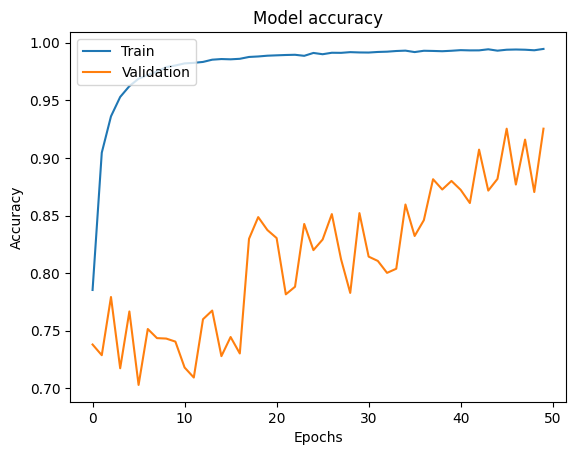

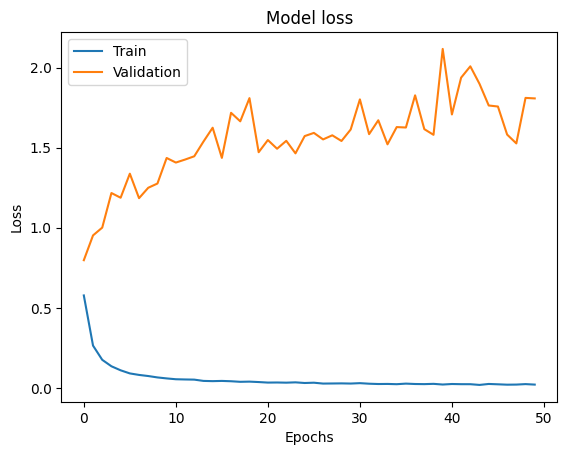

Confusion Matrix:
[[  56    4    4    0    0    2    0]
 [   1   88    2    1    3    7    1]
 [   5    2  182    0    5   26    0]
 [   0    0    0   21    1    1    0]
 [   1    3    6    0  185   28    0]
 [   3    7    7    0   19 1304    1]
 [   0    0    0    0    0    1   28]]


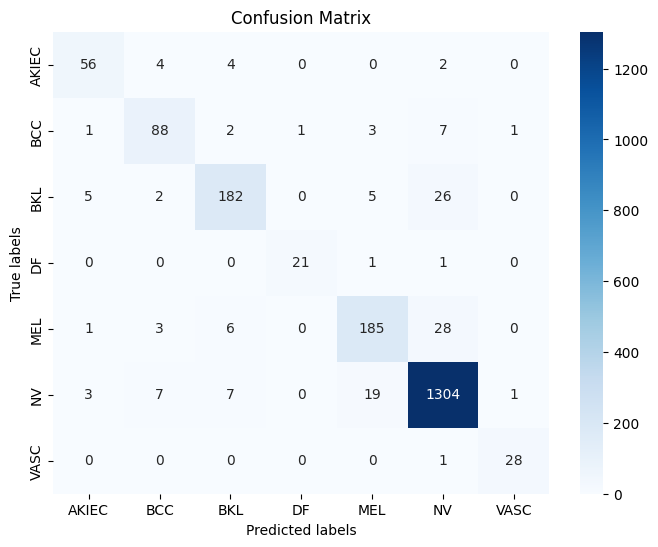


Classification Report:
              precision    recall  f1-score   support

           0     0.8485    0.8485    0.8485        66
           1     0.8462    0.8544    0.8502       103
           2     0.9055    0.8273    0.8646       220
           3     0.9545    0.9130    0.9333        23
           4     0.8685    0.8296    0.8486       223
           5     0.9525    0.9724    0.9624      1341
           6     0.9333    0.9655    0.9492        29

    accuracy                         0.9297      2005
   macro avg     0.9013    0.8872    0.8938      2005
weighted avg     0.9289    0.9297    0.9290      2005



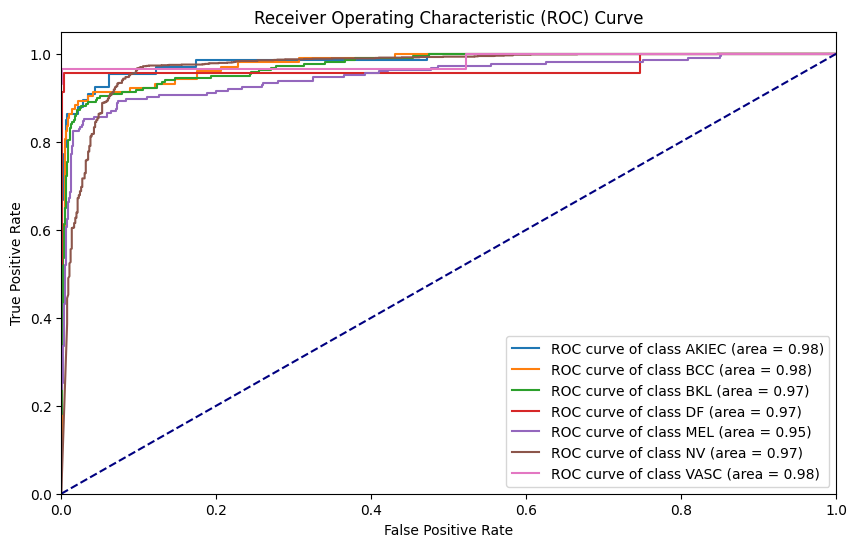

AUC: 0.962
AUC: 0.972


In [ ]:
y_train = np.load('/content/drive/MyDrive/HAM10000/paper4/dataset/y_train_f.npy')
y_test = np.load('/content/drive/MyDrive/HAM10000/paper4/dataset/y_test_f.npy')
y_train_onehot=np.argmax(y_train,axis=1)
y_test_onehot=np.argmax(y_test,axis=1)
print("Shape of y_train_onehot:", y_train_onehot.shape)  # Should be (N, num_classes)
print("Shape of y_test_onehot:", y_test_onehot.shape)

from sklearn.feature_selection import mutual_info_classif
# Compute Mutual Information Scores
mi_scores = mutual_info_classif(x_train_features_pca, y_train_onehot)

# Get Top-K Important Features (e.g., Select 1000 Best Features)
top_k = 2000
selected_features_idx = np.argsort(mi_scores)[-top_k:]  # Indices of top features
X_train_selected_mi = x_train_features_pca[:, selected_features_idx]  # Select top features

# Print new shape after feature selection
print("Original Shape:", x_train.shape)  # (4000, 4146)
print("Reduced Shape:", X_train_selected_mi.shape)  # (4000, 1000)

X_test_selected_mi = x_test_features_pca[:, selected_features_idx]  # Select top features

# Print new shape after feature selection
print("Original Shape:", x_test.shape)  # (4000, 4146)
print("Reduced Shape:", X_test_selected_mi.shape)  # (4000, 1000)

# Define MLP Model
model = Sequential([
    Dense(512, activation='relu', input_shape=(2000,)),  # Match input shape of selected features
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(7, activation='softmax')  # Multi-class classification (6 classes)
])

# Compile Model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train Model
history = model.fit(X_train_selected_mi, y_train, epochs=50, batch_size=32, validation_data=(X_test_selected_mi, y_test),verbose=0)
# Evaluate on Test Data
# test_loss, test_acc = model.evaluate(x_test_features_pca, y_test)
# print(f"Test Accuracy: {test_acc:.4f}")


# # ---------------------- Plot Accuracy & Loss ------------------------
# Plot Accuracy

plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')

# Plot Loss
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Loss')
plt.show()

# # ---------------------- Model Evaluation ------------------------
y_pred_probs = model.predict(X_test_selected_mi)  # Get prediction probabilities
np.save("/content/drive/MyDrive/HAM10000/paper4/mlp/x_test_prob_k2000_ham.npy",y_pred_probs)
y_pred = np.argmax(y_pred_probs, axis=1)  # Convert to class labels
np.save("/content/drive/MyDrive/HAM10000/paper4/mlp/x_test_pred_k2000_ham.npy",y_pred)


# Convert one-hot encoded y_test to class labels
y_test_labels = np.argmax(y_test, axis=1)  # Converts (461,6) → (461,)

# Convert softmax probabilities to predicted class labels
y_pred_labels = np.argmax(y_pred_probs, axis=1)  # Converts (461,6) → (461,)

# Generate classification report
print("\nClassification Report:\n", classification_report(y_test_labels, y_pred_labels))

# ---------------------- Colorful Confusion Matrix ------------------------
cm = confusion_matrix(y_test_labels, y_pred_labels)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm", xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# # ---------------------- AUC & ROC Curve ------------------------
y_true=np.argmax(y_test,axis=1)
y_true_binary = label_binarize(y_true, classes=np.unique(y_true))
n_classes = y_true_binary.shape[1]
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    # fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs.iloc[:, i])
    fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
# Plot ROC curve
plt.figure(figsize=(10, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label='ROC curve of class {0} (area = {1:0.2f})'.format(class_names[i], roc_auc[i]), linestyle='-')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()
auc1 = roc_auc_score(y_true, y_pred_probs,multi_class='ovo')
print('AUC: %.3f' % auc1)
auc2 = roc_auc_score(y_true, y_pred_probs,multi_class='ovr')
print('AUC: %.3f' % auc2)


###K=2500--94.16

Shape of y_train_onehot: (37548,)
Shape of y_test_onehot: (2005,)
Original Shape: (37548, 224, 224, 3)
Reduced Shape: (37548, 2500)
Original Shape: (2005, 224, 224, 3)
Reduced Shape: (2005, 2500)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


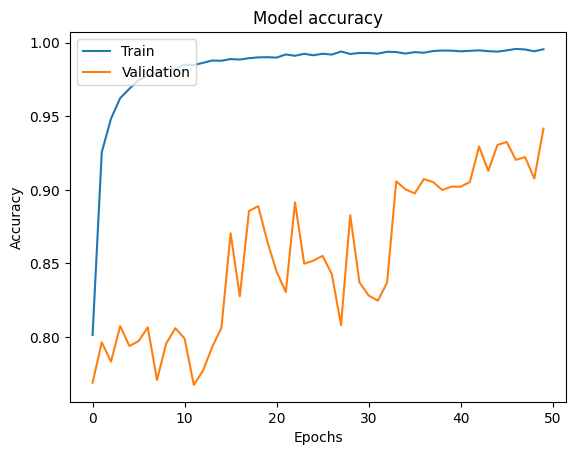

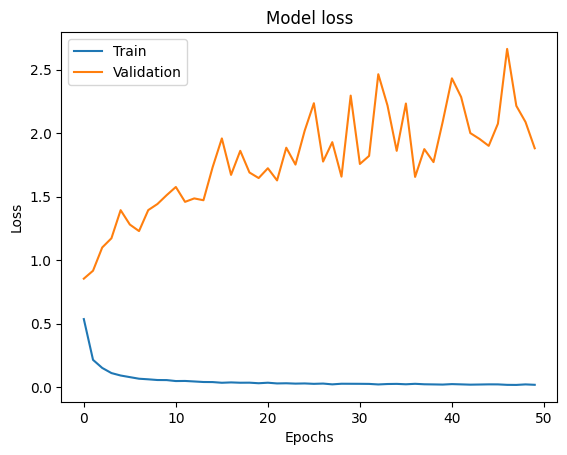

Confusion Matrix:
[[  60    0    3    0    0    3    0]
 [   1   90    2    0    0    9    1]
 [   4    1  190    0    2   23    0]
 [   0    0    0   21    1    1    0]
 [   1    4    1    0  195   22    0]
 [   1    6   10    0   19 1305    0]
 [   0    0    0    0    0    2   27]]


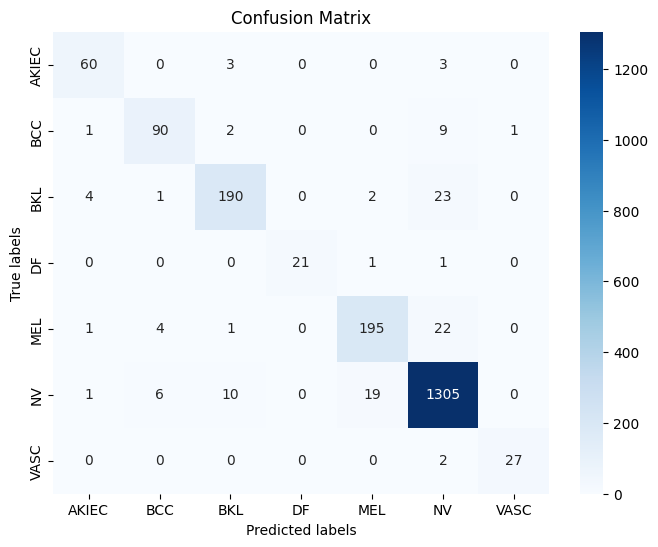


Classification Report:
              precision    recall  f1-score   support

           0     0.8955    0.9091    0.9023        66
           1     0.8911    0.8738    0.8824       103
           2     0.9223    0.8636    0.8920       220
           3     1.0000    0.9130    0.9545        23
           4     0.8986    0.8744    0.8864       223
           5     0.9560    0.9732    0.9645      1341
           6     0.9643    0.9310    0.9474        29

    accuracy                         0.9416      2005
   macro avg     0.9326    0.9055    0.9185      2005
weighted avg     0.9413    0.9416    0.9412      2005



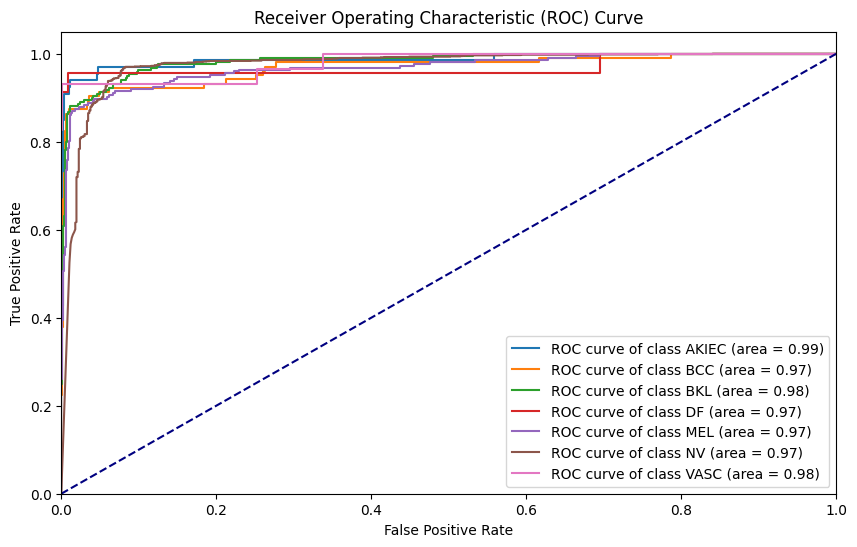

AUC: 0.968
AUC: 0.976


In [ ]:
y_train = np.load('/content/drive/MyDrive/HAM10000/paper4/dataset/y_train_f.npy')
y_test = np.load('/content/drive/MyDrive/HAM10000/paper4/dataset/y_test_f.npy')
y_train_onehot=np.argmax(y_train,axis=1)
y_test_onehot=np.argmax(y_test,axis=1)
print("Shape of y_train_onehot:", y_train_onehot.shape)  # Should be (N, num_classes)
print("Shape of y_test_onehot:", y_test_onehot.shape)

from sklearn.feature_selection import mutual_info_classif
# Compute Mutual Information Scores
mi_scores = mutual_info_classif(x_train_features_pca, y_train_onehot)

# Get Top-K Important Features (e.g., Select 1000 Best Features)
top_k = 2500
selected_features_idx = np.argsort(mi_scores)[-top_k:]  # Indices of top features
X_train_selected_mi = x_train_features_pca[:, selected_features_idx]  # Select top features

# Print new shape after feature selection
print("Original Shape:", x_train.shape)  # (4000, 4146)
print("Reduced Shape:", X_train_selected_mi.shape)  # (4000, 1000)

X_test_selected_mi = x_test_features_pca[:, selected_features_idx]  # Select top features

# Print new shape after feature selection
print("Original Shape:", x_test.shape)  # (4000, 4146)
print("Reduced Shape:", X_test_selected_mi.shape)  # (4000, 1000)

# Define MLP Model
model = Sequential([
    Dense(512, activation='relu', input_shape=(2500,)),  # Match input shape of selected features
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(7, activation='softmax')  # Multi-class classification (6 classes)
])

# Compile Model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train Model
history = model.fit(X_train_selected_mi, y_train, epochs=50, batch_size=32, validation_data=(X_test_selected_mi, y_test),verbose=0)
# Evaluate on Test Data
# test_loss, test_acc = model.evaluate(x_test_features_pca, y_test)
# print(f"Test Accuracy: {test_acc:.4f}")


# # ---------------------- Plot Accuracy & Loss ------------------------
# plt.figure(figsize=(12, 5))

# Plot Accuracy

plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')

# Plot Loss

plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Loss')

plt.show()

# # ---------------------- Model Evaluation ------------------------
y_pred_probs = model.predict(X_test_selected_mi)  # Get prediction probabilities
np.save("/content/drive/MyDrive/HAM10000/paper4/mlp/x_test_prob_k2500_ham.npy",y_pred_probs)
y_pred = np.argmax(y_pred_probs, axis=1)  # Convert to class labels
np.save("/content/drive/MyDrive/HAM10000/paper4/mlp/x_test_pred_k2500_ham.npy",y_pred)


# Convert one-hot encoded y_test to class labels
y_test_labels = np.argmax(y_test, axis=1)  # Converts (461,6) → (461,)

# Convert softmax probabilities to predicted class labels
y_pred_labels = np.argmax(y_pred_probs, axis=1)  # Converts (461,6) → (461,)

# Generate classification report
print("\nClassification Report:\n", classification_report(y_test_labels, y_pred_labels))

# ---------------------- Colorful Confusion Matrix ------------------------
cm = confusion_matrix(y_test_labels, y_pred_labels)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm", xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# # ---------------------- AUC & ROC Curve ------------------------
y_true=np.argmax(y_test,axis=1)
y_true_binary = label_binarize(y_true, classes=np.unique(y_true))
n_classes = y_true_binary.shape[1]
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    # fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs.iloc[:, i])
    fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
# Plot ROC curve
plt.figure(figsize=(10, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label='ROC curve of class {0} (area = {1:0.2f})'.format(class_names[i], roc_auc[i]), linestyle='-')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()
auc1 = roc_auc_score(y_true, y_pred_probs,multi_class='ovo')
print('AUC: %.3f' % auc1)
auc2 = roc_auc_score(y_true, y_pred_probs,multi_class='ovr')
print('AUC: %.3f' % auc2)




###K=3000--91.97

Shape of y_train_onehot: (37548,)
Shape of y_test_onehot: (2005,)
Original Shape: (37548, 224, 224, 3)
Reduced Shape: (37548, 3000)
Original Shape: (2005, 224, 224, 3)
Reduced Shape: (2005, 3000)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


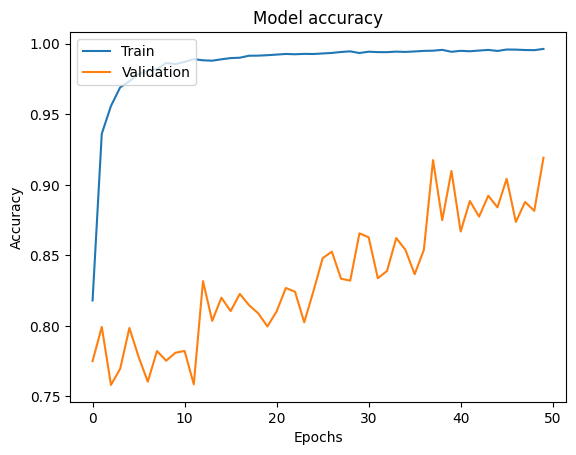

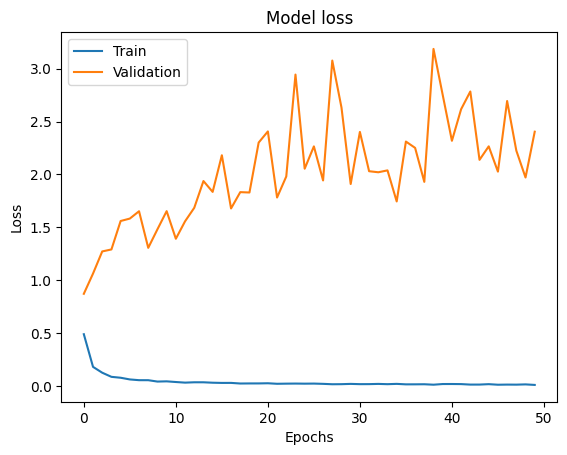

Confusion Matrix:
[[  52    2    8    0    0    4    0]
 [   1   88    5    0    3    6    0]
 [   2    1  182    0    3   32    0]
 [   0    1    1   16    1    4    0]
 [   1    0    9    0  171   42    0]
 [   0    8    9    1   15 1307    1]
 [   0    0    0    0    0    1   28]]


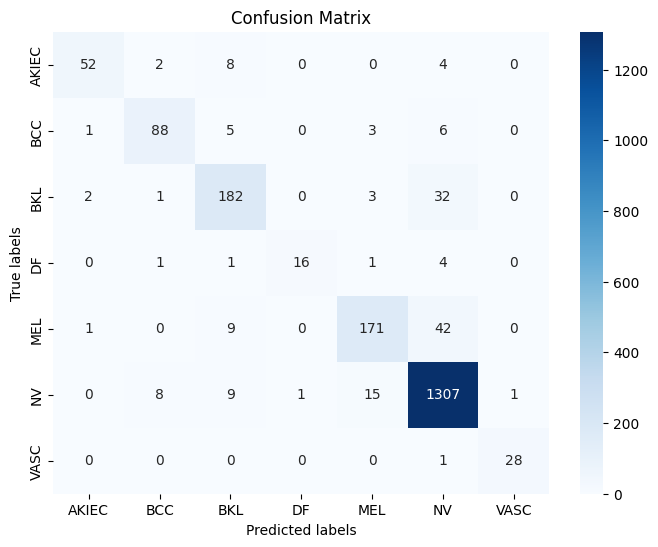


Classification Report:
              precision    recall  f1-score   support

           0     0.9286    0.7879    0.8525        66
           1     0.8800    0.8544    0.8670       103
           2     0.8505    0.8273    0.8387       220
           3     0.9412    0.6957    0.8000        23
           4     0.8860    0.7668    0.8221       223
           5     0.9362    0.9746    0.9551      1341
           6     0.9655    0.9655    0.9655        29

    accuracy                         0.9197      2005
   macro avg     0.9126    0.8389    0.8716      2005
weighted avg     0.9186    0.9197    0.9180      2005



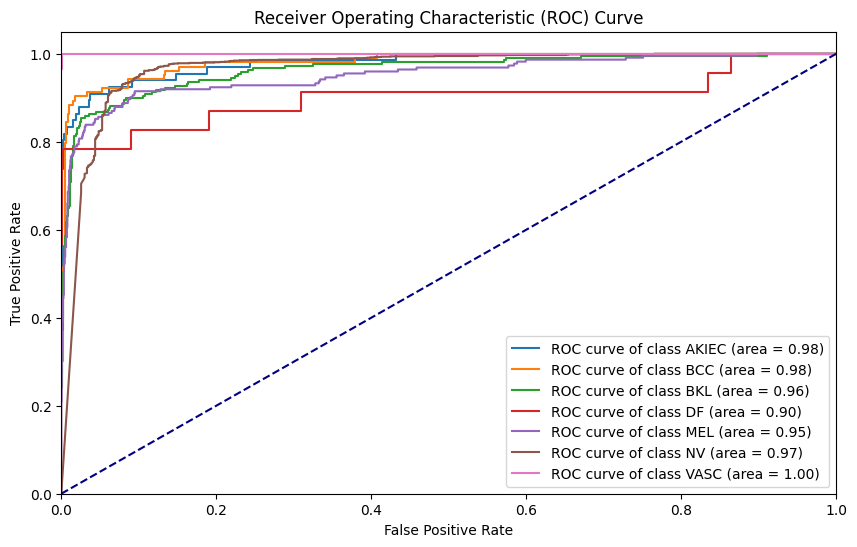

AUC: 0.949
AUC: 0.963


In [ ]:
y_train = np.load('/content/drive/MyDrive/HAM10000/paper4/dataset/y_train_f.npy')
y_test = np.load('/content/drive/MyDrive/HAM10000/paper4/dataset/y_test_f.npy')
y_train_onehot=np.argmax(y_train,axis=1)
y_test_onehot=np.argmax(y_test,axis=1)
print("Shape of y_train_onehot:", y_train_onehot.shape)  # Should be (N, num_classes)
print("Shape of y_test_onehot:", y_test_onehot.shape)

from sklearn.feature_selection import mutual_info_classif
# Compute Mutual Information Scores
mi_scores = mutual_info_classif(x_train_features_pca, y_train_onehot)

# Get Top-K Important Features (e.g., Select 1000 Best Features)
top_k = 3000
selected_features_idx = np.argsort(mi_scores)[-top_k:]  # Indices of top features
X_train_selected_mi = x_train_features_pca[:, selected_features_idx]  # Select top features

# Print new shape after feature selection
print("Original Shape:", x_train.shape)  # (4000, 4146)
print("Reduced Shape:", X_train_selected_mi.shape)  # (4000, 1000)

X_test_selected_mi = x_test_features_pca[:, selected_features_idx]  # Select top features

# Print new shape after feature selection
print("Original Shape:", x_test.shape)  # (4000, 4146)
print("Reduced Shape:", X_test_selected_mi.shape)  # (4000, 1000)

# Define MLP Model
model = Sequential([
    Dense(512, activation='relu', input_shape=(3000,)),  # Match input shape of selected features
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(7, activation='softmax')  # Multi-class classification (6 classes)
])

# Compile Model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train Model
history = model.fit(X_train_selected_mi, y_train, epochs=50, batch_size=32, validation_data=(X_test_selected_mi, y_test),verbose=0)

Evaluate on Test Data
test_loss, test_acc = model.evaluate(x_test_features_pca, y_test)
print(f"Test Accuracy: {test_acc:.4f}")


# # ---------------------- Plot Accuracy & Loss ------------------------
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Loss')

plt.show()

# # ---------------------- Model Evaluation ------------------------
y_pred_probs = model.predict(X_test_selected_mi)  # Get prediction probabilities
np.save("/content/drive/MyDrive/HAM10000/paper4/mlp/x_test_prob_k3000_ham.npy",y_pred_probs)
y_pred = np.argmax(y_pred_probs, axis=1)  # Convert to class labels
np.save("/content/drive/MyDrive/HAM10000/paper4/mlp/x_test_pred_k3000_ham.npy",y_pred)


# Convert one-hot encoded y_test to class labels
y_test_labels = np.argmax(y_test, axis=1)  # Converts (461,6) → (461,)

# Convert softmax probabilities to predicted class labels
y_pred_labels = np.argmax(y_pred_probs, axis=1)  # Converts (461,6) → (461,)

# Generate classification report
print("\nClassification Report:\n", classification_report(y_test_labels, y_pred_labels))

# ---------------------- Colorful Confusion Matrix ------------------------
cm = confusion_matrix(y_test_labels, y_pred_labels)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm", xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# # ---------------------- AUC & ROC Curve ------------------------
y_true=np.argmax(y_test,axis=1)
y_true_binary = label_binarize(y_true, classes=np.unique(y_true))
n_classes = y_true_binary.shape[1]
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    # fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs.iloc[:, i])
    fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
# Plot ROC curve
plt.figure(figsize=(10, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label='ROC curve of class {0} (area = {1:0.2f})'.format(class_names[i], roc_auc[i]), linestyle='-')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()
auc1 = roc_auc_score(y_true, y_pred_probs,multi_class='ovo')
print('AUC: %.3f' % auc1)
auc2 = roc_auc_score(y_true, y_pred_probs,multi_class='ovr')
print('AUC: %.3f' % auc2)


#Majority voting--99.30

In [ ]:
from scipy.stats import mode

# Load predictions from .npy files
m1x = np.load('/content/drive/MyDrive/HAM10000/paper4/gnet/x_test_pred_gnet_ham.npy')
m2x = np.load('/content/drive/MyDrive/HAM10000/paper4/dnet/x_test_pred_dnet_ham.npy')
m3x = np.load('/content/drive/MyDrive/HAM10000/paper4/mnet/x_test_pred_mnet_ham.npy')
m4x = np.load('/content/drive/MyDrive/HAM10000/paper4/nnet/x_test_pred_nnet_ham.npy')
m5x = np.load('/content/drive/MyDrive/HAM10000/paper4/irnet/x_test_pred_irnet_ham.npy')
m6x = np.load('/content/drive/MyDrive/HAM10000/paper4/ccnngru/x_test_pred_ccnngru_ham.npy')
m7x = np.load('/content/drive/MyDrive/HAM10000/paper4/svm/x_test_pred_svm_ham.npy')
m8x = np.load('/content/drive/MyDrive/HAM10000/paper4/mlp/x_test_prob_k2500_ham.npy')
m8x=np.argmax(m8x,axis=1)
print("m1x shape=",m1x.shape)
print("m2x shape=",m2x.shape)
print("m3x shape=",m3x.shape)
print("m4x shape=",m4x.shape)
print("m5x shape=",m5x.shape)
print("m6x shape=",m6x.shape)
print("m7x shape=",m7x.shape)
print("m8x shape=",m8x.shape)



# Stack predictions to shape (num_samples, 3)
all_predictions = np.vstack((m1x,m2x,m3x,m4x,m5x,m6x,m7x,m8x))  # Transpose to get (num_samples, 3)


# Apply Majority Voting - Get the most frequent class in each row
final_predictions, _ = mode(all_predictions, axis=1, keepdims=False)

# If ground truth labels are available, evaluate accuracy
y_test = np.load('/content/drive/MyDrive/HAM10000/paper4/dataset/y_test_f.npy')



y_test_labels= np.argmax(y_test, axis=1)
# Store models in a list
models = [m1x, m2x, m3x, m4x, m5x, m6x,m7x,m8x]
model_names = ['m1', 'm2', 'm3', 'm4', 'm5', 'm6','m7','m8']

# Generate all possible combinations of 2, 3, 4, and 5 models
best_accuracy = 0
best_combination = None

for r in range(2, 9):  # From 2-model to 5-model combinations
    for combo in combinations(range(8), r):  # Get index combinations
        selected_models = [models[i] for i in combo]
        selected_names = [model_names[i] for i in combo]

        # Stack selected models and apply majority voting
        all_predictions = np.vstack(selected_models).T  # Shape (num_samples, r)
        final_predictions, _ = mode(all_predictions, axis=1, keepdims=False)

        # Compute accuracy
        accuracy = accuracy_score(y_test_labels, final_predictions)

        # Print result
        print(f"Combination: {selected_names}, Test Accuracy: {accuracy * 100:.2f}%")

        # Track best combination
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_combination = selected_names

# Print best model combination
print("\nBest Combination:", best_combination, f"with Accuracy: {best_accuracy * 100:.2f}%")

m1x shape= (2005,)
m2x shape= (2005,)
m3x shape= (2005,)
m4x shape= (2005,)
m5x shape= (2005,)
m6x shape= (2005,)
m7x shape= (2005,)
m8x shape= (2005,)
Combination: ['m1', 'm2'], Test Accuracy: 83.69%
Combination: ['m1', 'm3'], Test Accuracy: 82.94%
Combination: ['m1', 'm4'], Test Accuracy: 77.56%
Combination: ['m1', 'm5'], Test Accuracy: 78.90%
Combination: ['m1', 'm6'], Test Accuracy: 85.49%
Combination: ['m1', 'm7'], Test Accuracy: 84.84%
Combination: ['m1', 'm8'], Test Accuracy: 85.19%
Combination: ['m2', 'm3'], Test Accuracy: 92.22%
Combination: ['m2', 'm4'], Test Accuracy: 84.84%
Combination: ['m2', 'm5'], Test Accuracy: 85.49%
Combination: ['m2', 'm6'], Test Accuracy: 93.72%
Combination: ['m2', 'm7'], Test Accuracy: 92.92%
Combination: ['m2', 'm8'], Test Accuracy: 93.37%
Combination: ['m3', 'm4'], Test Accuracy: 85.04%
Combination: ['m3', 'm5'], Test Accuracy: 85.14%
Combination: ['m3', 'm6'], Test Accuracy: 94.26%
Combination: ['m3', 'm7'], Test Accuracy: 93.42%
Combination: ['

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
# Full model name mapping
model_names = {
    'M1': 'GoogleNet',
    'M2': 'DenseNet201',
    'M3': 'MobileNetV2',
    'M4': 'NASNet',
    'M5': 'InceptionResNetV2',
    'M6': 'PHMBCNNGRU',
    'M7': 'SVM',
    'M8': 'MLP'

}
# Your dictionary
data = {

    2: {83.69, 82.94, 77.56, 78.90, 85.49, 84.84, 85.19, 92.22, 84.84, 85.49,
        93.72, 92.92, 93.37, 85.04, 85.14, 94.26, 93.42, 93.72, 79.25, 86.93,
        86.23, 86.38, 86.88, 86.28, 86.63, 95.11, 95.61, 94.71},
    3: {94.71, 92.57, 92.67, 95.91, 95.51, 95.81, 93.27, 92.77, 96.21, 95.81,
        95.76, 90.77, 94.21, 93.87, 93.77, 93.52, 93.07, 93.42, 95.71, 97.16,
        96.71, 95.86, 96.21, 97.86, 97.56, 97.31, 94.06, 97.06, 96.91, 96.26,
        96.81, 96.36, 96.26, 95.91, 98.45, 98.20, 94.71, 97.11, 96.76, 96.11,
        97.41, 97.06, 96.76, 95.91, 97.91, 97.76, 95.51, 95.01, 95.46, 95.76,
        97.86, 97.46, 95.66, 97.56, 97.26, 95.96},
    4:{95.76, 95.51, 97.16, 97.06, 97.31, 93.77, 96.16, 96.01, 96.16, 95.91,
        95.71, 95.81, 95.91, 98.15, 98.05, 94.01, 96.31, 96.21, 96.01, 96.11,
        95.86, 95.71, 96.41, 97.71, 97.61, 94.36, 94.16, 94.61, 95.66, 96.86,
       96.71, 94.76, 96.56, 96.31, 96.86, 96.31, 98.10, 97.86, 98.05, 98.05,
        97.91, 97.81, 97.01, 98.70, 98.65, 96.66, 96.36, 96.71, 96.56, 98.50,
        98.25, 96.46, 98.35, 98.20, 97.36, 96.86, 96.61, 96.96, 96.71, 98.35,
        98.15, 96.76, 98.05, 98.00, 97.06, 95.61, 97.61, 97.31, 96.96, 96.81},
    5:{96.46, 98.20, 98.10, 98.15, 97.66, 97.61, 97.36, 97.66, 98.65, 98.60,
       96.91, 96.81, 96.91, 97.16, 98.45, 98.30, 97.01, 97.81, 97.66, 98.00,
       97.56, 97.46, 97.51, 97.31, 98.25, 98.20, 97.46, 98.15, 98.05, 97.96,
       96.46, 97.71, 97.56, 97.76, 97.56, 98.60, 98.50, 98.30, 98.00, 99.29,
       99.20, 97.91, 98.90, 98.75, 98.65, 97.71, 98.75, 98.55, 98.65, 98.25,
       97.76, 98.80, 98.70, 98.35, 98.05, 97.76},
    6:{98.05, 98.00, 97.86, 97.96, 98.95, 98.80, 98.00, 98.50, 98.40, 98.50,
       97.71, 98.40, 98.30, 98.50, 98.40, 97.76, 98.55, 98.40, 98.35, 98.20,
       97.86, 98.55, 99.10, 98.95, 98.85, 98.75, 98.70, 98.35},
    7:{98.55, 98.95, 98.95, 99.00,
        98.75, 98.80, 98.65, 99.30},
    8:{99.10}
}

# Convert to DataFrame
rows = []
for key, values in data.items():
    for val in values:
        rows.append({'Key': key, 'Value': val})

df = pd.DataFrame(rows)

# Find the max value
max_val = df['Value'].max()

# Add color column
df['Color'] = df['Value'].apply(lambda x: 'red' if x == max_val else 'skyblue')

# Plot
plt.figure(figsize=(10,5), dpi=300)
for i, row in df.iterrows():
    plt.scatter(row['Key'], row['Value'], color=row['Color'], s=75)
                # , edgecolor='black')
    if row['Color'] == 'red':
        plt.text(row['Key'], row['Value'] + 0.4, f"{{M1,M2,M3,M4,M5,M6,M7,M8}} = {row['Value']}%",
                 ha='right', va='bottom', fontsize=12, color='red')
# Set x-axis to show only unique keys
plt.xticks(sorted(data.keys()), fontsize=10)
plt.yticks(range(76, 101, 2),fontsize=10)
plt.ylim(76, 101)

# Combined legend text box
legend_text = "Legend:\n• Best Combination (red dot)\n\nModel Names:\n" + '\n'.join([f"{k} = {v}" for k, v in model_names.items()])
plt.gcf().text(0.79, 0.15, legend_text, fontsize=8.5, va='bottom', bbox=dict(facecolor='white', edgecolor='gray'))

# Labels & layout
# plt.title('Strip Plot (Highlight Highest Value)')
plt.xlabel("Number of Models in Combination", fontsize=10)
plt.ylabel("Accuracy (%)", fontsize=10)
plt.title("SVM classifier Accuracy Visualization on Model Combinations", fontsize=12, weight='bold')
# plt.xlabel('Key')
# plt.ylabel('Value')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


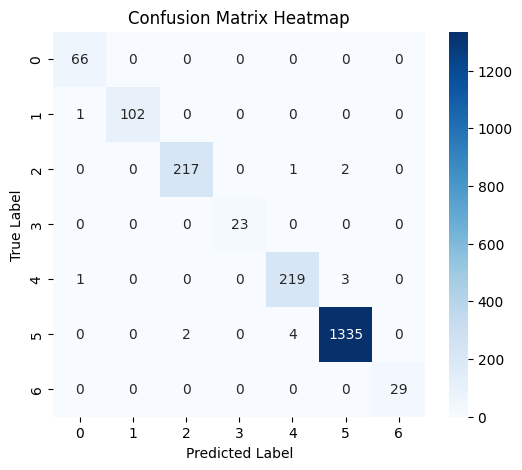

Classification Report:
               precision    recall  f1-score   support

           0     0.9706    1.0000    0.9851        66
           1     1.0000    0.9903    0.9951       103
           2     0.9909    0.9864    0.9886       220
           3     1.0000    1.0000    1.0000        23
           4     0.9777    0.9821    0.9799       223
           5     0.9963    0.9955    0.9959      1341
           6     1.0000    1.0000    1.0000        29

    accuracy                         0.9930      2005
   macro avg     0.9908    0.9935    0.9921      2005
weighted avg     0.9931    0.9930    0.9930      2005

Accuracy: 0.9930
Precision: 0.9931, Recall: 0.9930, F1-score: 0.9930
Matthews Correlation Coefficient: 0.9867
Cohen's Kappa Score: 0.9867


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, roc_auc_score, cohen_kappa_score, matthews_corrcoef

m2x = np.load('/content/drive/MyDrive/HAM10000/paper4/dnet/x_test_pred_dnet_ham.npy')
m3x = np.load('/content/drive/MyDrive/HAM10000/paper4/mnet/x_test_pred_mnet_ham.npy')
m4x = np.load('/content/drive/MyDrive/HAM10000/paper4/nnet/x_test_pred_nnet_ham.npy')
# m5x = np.load('/content/drive/MyDrive/HAM10000/paper4/irnet/x_test_pred_irnet_ham.npy')
m6x = np.load('/content/drive/MyDrive/HAM10000/paper4/ccnngru/x_test_pred_ccnngru_ham.npy')
# m7x = np.load('/content/drive/MyDrive/HAM10000/paper4/svm/x_test_pred_svm_ham.npy')
m8x = np.load('/content/drive/MyDrive/HAM10000/paper4/mlp/x_test_prob_k2500_ham.npy')
m8x=np.argmax(m8x,axis=1)
# Stack predictions to shape (num_samples, 3)
all_predictions = np.vstack((m2x,m3x,m4x,m6x,m8x))  # Transpose to get (num_samples, 3)


# Apply Majority Voting - Get the most frequent class in each row
# final_predictions, _ = mode(all_predictions, axis=1, keepdims=False)
final_preds = np.array([np.bincount(preds).argmax() for preds in zip(m2x,m3x,m4x,m6x,m8x)])


# If ground truth labels are available, evaluate accuracy
y_test = np.load('/content/drive/MyDrive/HAM10000/paper4/dataset/y_test_f.npy')
y_true= np.argmax(y_test, axis=1)

# Compute Confusion Matrix
conf_matrix = confusion_matrix(y_true, final_preds)

# Plot Confusion Matrix Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y_true), yticklabels=np.unique(y_true))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

# Print Classification Report
print("Classification Report:\n", classification_report(y_true, final_preds,digits=4))

# Performance Metrics
accuracy = accuracy_score(y_true, final_preds)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, final_preds, average='weighted')
# conf_matrix = confusion_matrix(y_true, final_preds)
mcc = matthews_corrcoef(y_true, final_preds)
cohen_kappa = cohen_kappa_score(y_true, final_preds)

# Print results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")
# print(f"Confusion Matrix:\n{conf_matrix}")
print(f"Matthews Correlation Coefficient: {mcc:.4f}")
print(f"Cohen's Kappa Score: {cohen_kappa:.4f}")

